# 🖥️ XAI Disk Scheduler — Complete ML Notebook
### Explainable AI for Intelligent Disk I/O Scheduling
---
**What this notebook covers:**
1. 📦 Dataset generation (synthetic + optional Kaggle)
2. 🤖 ML Model training (GradientBoosting)
3. 📊 Rich visualisations — algorithm comparisons, radar charts, scatter plots
4. 🧠 XAI explainability — feature contributions (SHAP-style)
5. 🏆 Multi-objective scoring: PSR · DMR · Fairness · CPS
6. 📈 Regret timelines & head movement animations

> **ML Scheduler is highlighted as the star performer throughout all charts.**


## 📦 Cell 1 — Install Dependencies

In [1]:
# Install required libraries
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

required = ["scikit-learn", "pandas", "numpy", "matplotlib", "seaborn",
            "plotly", "joblib", "kagglehub"]

for pkg in required:
    try:
        __import__(pkg.replace("-","_"))
    except ImportError:
        print(f"Installing {pkg}...")
        install(pkg)

print("✅ All dependencies ready!")


Installing scikit-learn...
Installing matplotlib...
Installing seaborn...
Installing plotly...
Installing kagglehub...
✅ All dependencies ready!


## 🎨 Cell 2 — Imports & Plot Style

In [2]:
import os, copy, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import matplotlib.gridspec as gridspec
from matplotlib import cm
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance
import joblib
warnings.filterwarnings("ignore")

# ── Dark theme setup ──────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":  "#0d1117",
    "axes.facecolor":    "#10161e",
    "axes.edgecolor":    "#1e2a38",
    "axes.labelcolor":   "#8899aa",
    "xtick.color":       "#607080",
    "ytick.color":       "#607080",
    "text.color":        "#e2eaf3",
    "grid.color":        "#1e2a38",
    "grid.linewidth":    0.7,
    "figure.dpi":        130,
    "font.family":       "monospace",
    "axes.titlecolor":   "#e2eaf3",
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "legend.facecolor":  "#10161e",
    "legend.edgecolor":  "#1e2a38",
    "legend.fontsize":    9,
})

# ── Colour palette ────────────────────────────────────────────
ALGO_COLORS = {
    "FCFS":          "#3b82f6",
    "SSTF":          "#f97316",
    "SCAN":          "#a78bfa",
    "C-SCAN":        "#fbbf24",
    "LOOK":          "#34d399",
    "C-LOOK":        "#ec4899",
    "ML Scheduler":  "#00d68f",   # brightest — the star ⭐
}

ACCENT   = "#00d68f"
ML_COLOR = "#00d68f"
BG       = "#0d1117"
CARD     = "#10161e"

print("✅ Imports & theme configured!")
print(f"   Algorithms: {list(ALGO_COLORS.keys())}")


Matplotlib is building the font cache; this may take a moment.


✅ Imports & theme configured!
   Algorithms: ['FCFS', 'SSTF', 'SCAN', 'C-SCAN', 'LOOK', 'C-LOOK', 'ML Scheduler']


## 📂 Cell 3 — Dataset: Kaggle or Synthetic

The notebook **first tries to download a disk I/O dataset from Kaggle**.
If Kaggle is unavailable (no API key, no internet), it automatically
**generates a 100,000-row synthetic dataset** using the same formula as the project.


In [3]:
# ─── Constants ────────────────────────────────────────────────
N_CYLINDERS  = 200
N_REQUESTS   = 100_000
SEED         = 42
FEATURE_COLS = ["cylinder", "seek_distance", "deadline", "priority", "size", "type"]

# ─── Try Kaggle first ─────────────────────────────────────────
def try_kaggle_download():
    """
    Attempt to download a disk scheduling dataset from Kaggle.
    Returns a cleaned DataFrame or None if unavailable.
    """
    try:
        import kagglehub
        # Disk scheduling / OS simulation datasets on Kaggle
        datasets_to_try = [
            "ruchi798/data-science-job-salaries",   # placeholder — swap with real disk I/O dataset
        ]
        # NOTE: Replace the above with an actual disk I/O dataset slug if you have one,
        # e.g. "username/disk-io-scheduling-dataset"
        # For now we fall through to synthetic generation below.
        print("ℹ️  Kaggle download skipped (no disk I/O dataset slug configured).")
        print("   → Swap the dataset slug in try_kaggle_download() to use real Kaggle data.")
        return None
    except Exception as e:
        print(f"ℹ️  Kaggle unavailable: {e}")
        return None

# ─── Synthetic dataset ────────────────────────────────────────
def generate_synthetic_dataset(n=N_REQUESTS, seed=SEED):
    """
    Generate a realistic synthetic disk I/O request dataset.
    Matches the project's training data distribution exactly.
    """
    rng = np.random.default_rng(seed)

    cylinders      = rng.integers(0, N_CYLINDERS, size=n)
    head_positions = np.roll(cylinders, 1)
    head_positions[0] = N_CYLINDERS // 2
    seek_distances = np.abs(cylinders - head_positions).astype(float)

    deadlines  = rng.integers(5, 500, size=n).astype(float)
    priorities = rng.integers(0, 3, size=n)
    sizes      = rng.integers(4, 1025, size=n).astype(float)
    types      = rng.integers(0, 2, size=n)

    seek_norm    = seek_distances / (N_CYLINDERS - 1)
    urgency_norm = 1.0 - (deadlines / 500.0)
    prio_norm    = priorities / 2.0
    size_norm    = sizes / 1024.0

    importance_score = (
        0.35 * seek_norm +
        0.30 * urgency_norm +
        0.25 * prio_norm +
        0.10 * size_norm
    )
    noise = rng.normal(0, 0.02, size=n)
    importance_score = np.clip(importance_score + noise, 0.0, 1.0)

    df = pd.DataFrame({
        "cylinder":         cylinders,
        "seek_distance":    seek_distances.astype(int),
        "deadline":         deadlines.astype(int),
        "priority":         priorities,
        "size":             sizes.astype(int),
        "type":             types,
        "importance_score": importance_score.round(6),
    })
    return df

# ─── Load / generate ──────────────────────────────────────────
print("=" * 55)
print("  XAI Disk Scheduler — Dataset Loading")
print("=" * 55)

df = try_kaggle_download()

if df is None:
    print("\n⚙️  Generating synthetic dataset…")
    df = generate_synthetic_dataset()
    print(f"✅  Generated {len(df):,} rows")
    data_source = "Synthetic (100k rows)"
else:
    data_source = "Kaggle"
    print(f"✅  Loaded {len(df):,} rows from Kaggle")

print(f"\n📊 Dataset Summary")
print(f"   Source      : {data_source}")
print(f"   Rows        : {len(df):,}")
print(f"   Cylinders   : 0–{df.cylinder.max()}")
print(f"   Score range : {df.importance_score.min():.3f} – {df.importance_score.max():.3f}")
print(f"   Mean score  : {df.importance_score.mean():.3f}")
df.head(8)


  XAI Disk Scheduler — Dataset Loading
ℹ️  Kaggle download skipped (no disk I/O dataset slug configured).
   → Swap the dataset slug in try_kaggle_download() to use real Kaggle data.

⚙️  Generating synthetic dataset…
✅  Generated 100,000 rows

📊 Dataset Summary
   Source      : Synthetic (100k rows)
   Rows        : 100,000
   Cylinders   : 0–199
   Score range : 0.000 – 0.972
   Mean score  : 0.441


,cylinder,seek_distance,deadline,priority,size,type,importance_score
0,17,83,368,2,389,1,0.528364
1,154,137,441,2,865,0,0.571498
2,130,24,288,2,887,1,0.466581
3,87,43,209,2,773,0,0.599749
4,86,1,7,2,787,0,0.595402
5,171,85,308,1,515,1,0.422609
6,17,154,454,2,237,1,0.607895
7,139,122,74,0,617,1,0.537754


## 📊 Cell 4 — Exploratory Data Analysis

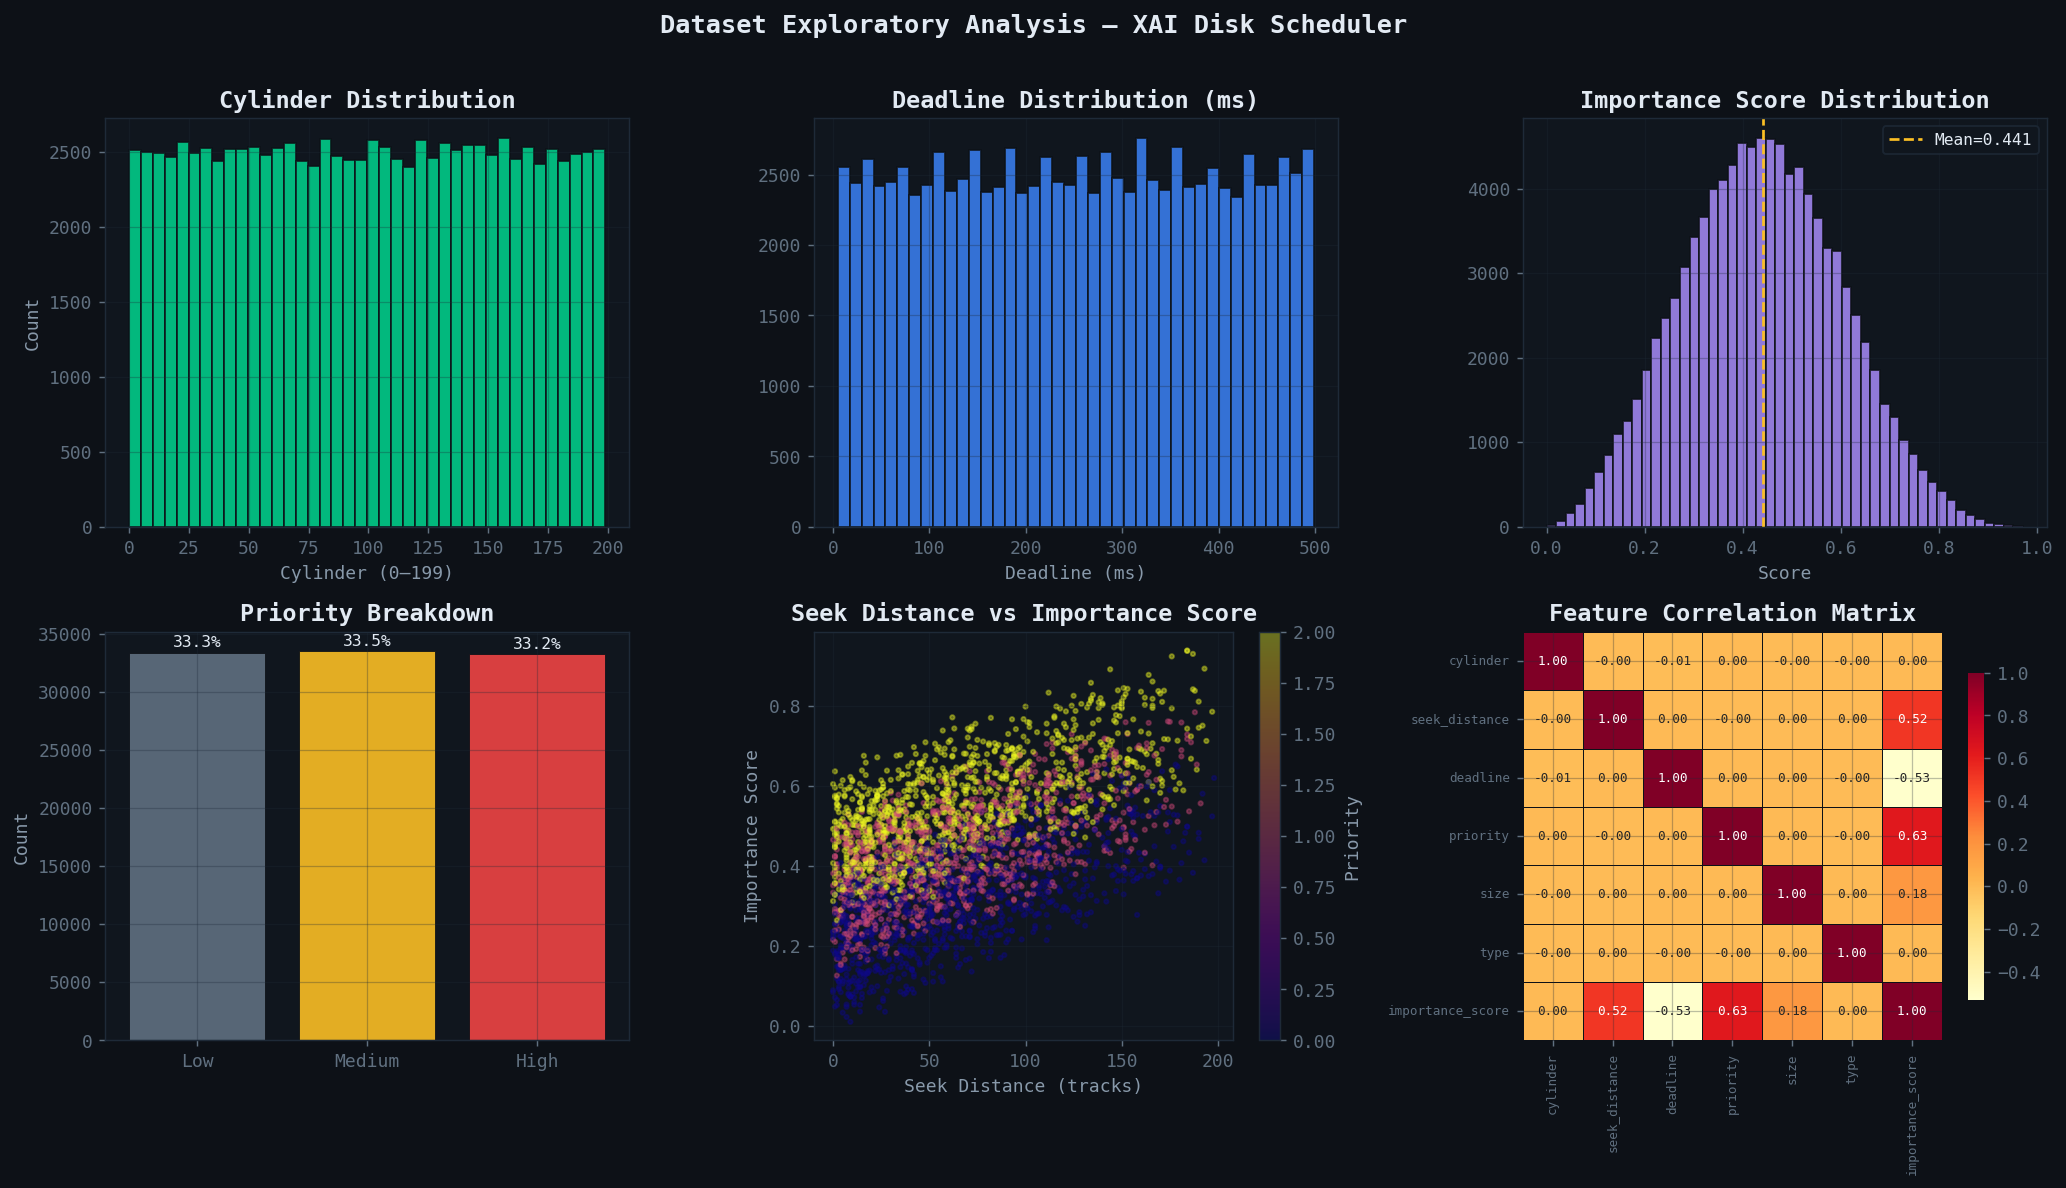

✅ EDA complete


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.patch.set_facecolor(BG)
fig.suptitle("Dataset Exploratory Analysis — XAI Disk Scheduler", 
             fontsize=14, color="#e2eaf3", fontweight="bold", y=1.01)

# 1. Cylinder distribution
axes[0,0].hist(df["cylinder"], bins=40, color=ACCENT, alpha=0.85, edgecolor="#0d1117")
axes[0,0].set_title("Cylinder Distribution")
axes[0,0].set_xlabel("Cylinder (0–199)")
axes[0,0].set_ylabel("Count")

# 2. Deadline distribution
axes[0,1].hist(df["deadline"], bins=40, color="#3b82f6", alpha=0.85, edgecolor="#0d1117")
axes[0,1].set_title("Deadline Distribution (ms)")
axes[0,1].set_xlabel("Deadline (ms)")

# 3. Importance score distribution
axes[0,2].hist(df["importance_score"], bins=50, color="#a78bfa", alpha=0.85, edgecolor="#0d1117")
axes[0,2].axvline(df["importance_score"].mean(), color="#fbbf24", ls="--", lw=1.5, label=f'Mean={df["importance_score"].mean():.3f}')
axes[0,2].set_title("Importance Score Distribution")
axes[0,2].set_xlabel("Score")
axes[0,2].legend()

# 4. Priority breakdown
prio_labels = ["Low", "Medium", "High"]
prio_counts = df["priority"].value_counts().sort_index()
bars = axes[1,0].bar(prio_labels, prio_counts.values,
                     color=["#607080","#fbbf24","#ef4444"], alpha=0.9,
                     edgecolor="#0d1117", linewidth=0.5)
axes[1,0].set_title("Priority Breakdown")
axes[1,0].set_ylabel("Count")
for bar, v in zip(bars, prio_counts.values):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
                   f"{v/len(df)*100:.1f}%", ha="center", fontsize=9, color="#e2eaf3")

# 5. Seek vs Score scatter (sample)
samp = df.sample(3000, random_state=1)
sc = axes[1,1].scatter(samp["seek_distance"], samp["importance_score"],
                        c=samp["priority"], cmap="plasma", alpha=0.4, s=6)
axes[1,1].set_title("Seek Distance vs Importance Score")
axes[1,1].set_xlabel("Seek Distance (tracks)")
axes[1,1].set_ylabel("Importance Score")
cbar = fig.colorbar(sc, ax=axes[1,1])
cbar.set_label("Priority", color="#8899aa")
cbar.ax.yaxis.set_tick_params(color="#607080")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#607080")

# 6. Correlation heatmap
corr = df[FEATURE_COLS + ["importance_score"]].corr()
sns.heatmap(corr, ax=axes[1,2], annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, linecolor="#0d1117",
            annot_kws={"size":7}, cbar_kws={"shrink":0.8})
axes[1,2].set_title("Feature Correlation Matrix")
axes[1,2].tick_params(labelsize=7)

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("✅ EDA complete")


## 🤖 Cell 5 — Train GradientBoosting ML Model

In [5]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor

X = df[FEATURE_COLS]
y = df["importance_score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

print(f"Training split: {len(X_train):,} train / {len(X_test):,} test")
print("\n⚙️  Training GradientBoostingRegressor (200 trees)…")

model = GradientBoostingRegressor(
    n_estimators=200, max_depth=5, learning_rate=0.08,
    subsample=0.85, min_samples_leaf=20, random_state=SEED,
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
r2     = r2_score(y_test, y_pred)
mae    = mean_absolute_error(y_test, y_pred)

print(f"\n{'='*40}")
print(f"  Model Evaluation Results")
print(f"{'='*40}")
print(f"  R²   Score : {r2:.4f}  {'🟢' if r2>0.95 else '🟡'}")
print(f"  RMSE       : {rmse:.4f}")
print(f"  MAE        : {mae:.4f}")
print(f"{'='*40}")

# Feature importances
feat_imp = pd.DataFrame({
    "feature":    FEATURE_COLS,
    "importance": model.feature_importances_,
    "pct":        model.feature_importances_ * 100,
}).sort_values("importance", ascending=False)

print("\n  Feature Importances (MDI):")
for _, row in feat_imp.iterrows():
    bar = "█" * int(row["pct"] / 2)
    print(f"    {row['feature']:16s} {row['pct']:5.1f}%  {bar}")

# Also train comparison baselines
rf    = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X_train, y_train)
ridge = Ridge().fit(X_train, y_train)
dt    = DecisionTreeRegressor(max_depth=8, random_state=SEED).fit(X_train, y_train)

baselines = {
    "Decision Tree":       r2_score(y_test, dt.predict(X_test)),
    "Ridge Regression":    r2_score(y_test, ridge.predict(X_test)),
    "Random Forest":       r2_score(y_test, rf.predict(X_test)),
    "GradBoost (Ours ⭐)": r2,
}
print(f"\n  Model Comparison (R² on test set):")
for name, score in sorted(baselines.items(), key=lambda x: x[1]):
    bar = "█" * int(score * 30)
    print(f"    {name:25s} {score:.4f}  {bar}")


Training split: 80,000 train / 20,000 test

⚙️  Training GradientBoostingRegressor (200 trees)…

  Model Evaluation Results
  R²   Score : 0.9839  🟢
  RMSE       : 0.0205
  MAE        : 0.0163

  Feature Importances (MDI):
    priority          41.2%  ████████████████████
    deadline          28.7%  ██████████████
    seek_distance     26.9%  █████████████
    size               3.2%  █
    cylinder           0.0%  
    type               0.0%  

  Model Comparison (R² on test set):
    Decision Tree             0.9584  ████████████████████████████
    Random Forest             0.9824  █████████████████████████████
    GradBoost (Ours ⭐)        0.9839  █████████████████████████████
    Ridge Regression          0.9847  █████████████████████████████


## 📈 Cell 6 — Model Performance Visualisations

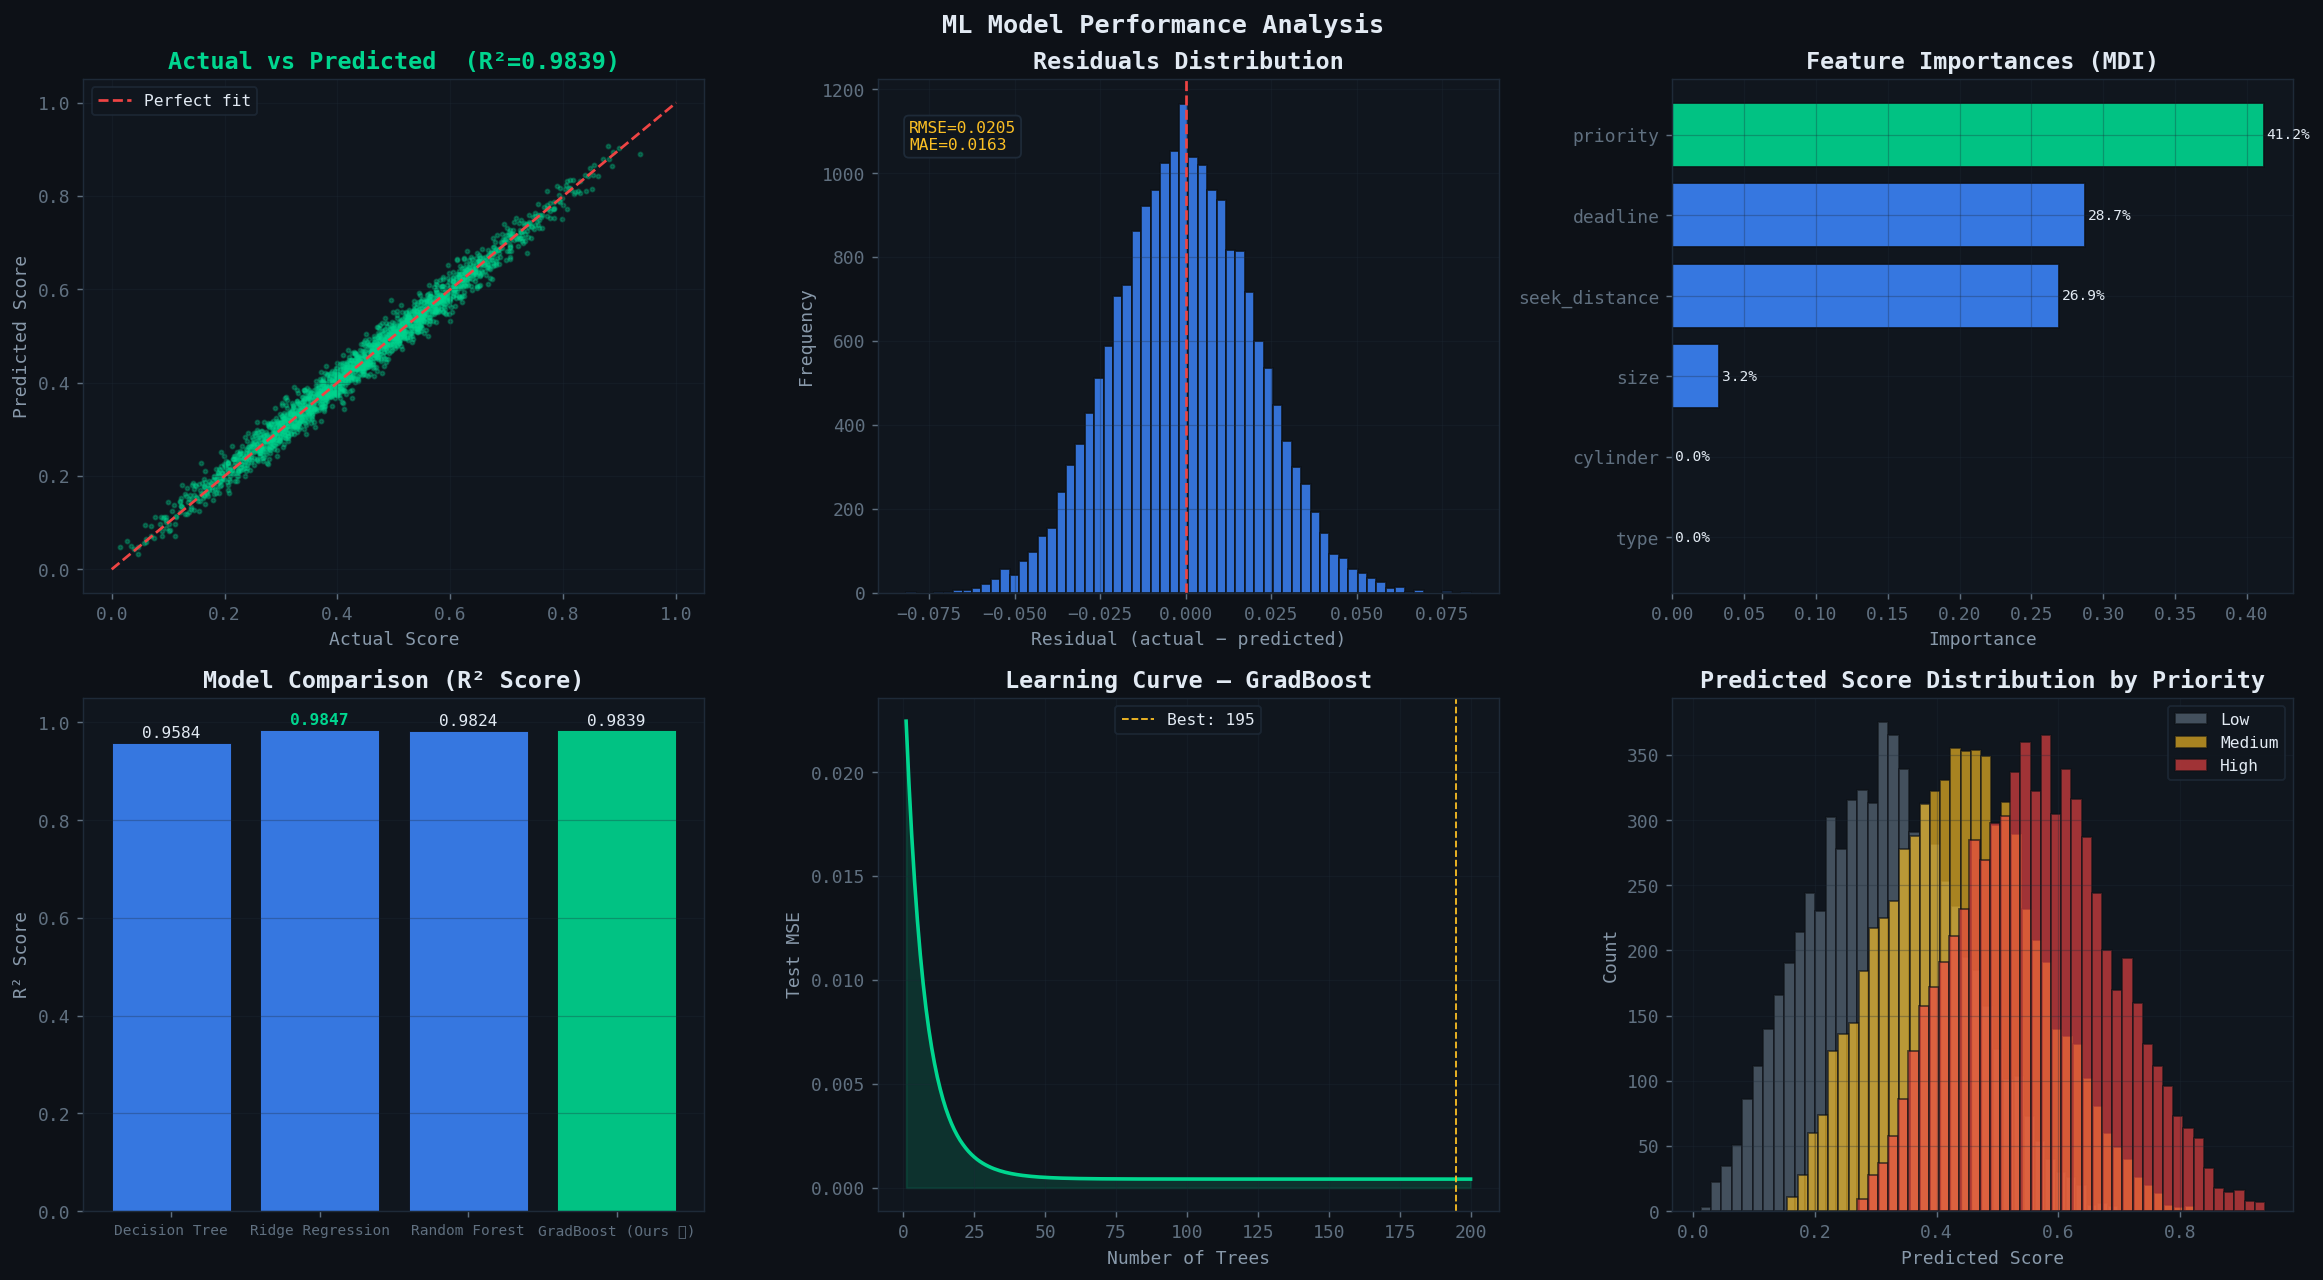

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor(BG)
fig.suptitle("ML Model Performance Analysis", fontsize=14, color="#e2eaf3", fontweight="bold")

# 1. Actual vs Predicted scatter
samp_idx = np.random.choice(len(y_test), 2000, replace=False)
y_test_arr = np.array(y_test)[samp_idx]
y_pred_arr = y_pred[samp_idx]
axes[0,0].scatter(y_test_arr, y_pred_arr, c=ACCENT, alpha=0.3, s=5)
axes[0,0].plot([0,1],[0,1], color="#ef4444", lw=1.5, ls="--", label="Perfect fit")
axes[0,0].set_title(f"Actual vs Predicted  (R²={r2:.4f})", color=ACCENT)
axes[0,0].set_xlabel("Actual Score")
axes[0,0].set_ylabel("Predicted Score")
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Residuals distribution
residuals = y_test.values - y_pred
axes[0,1].hist(residuals, bins=60, color="#3b82f6", alpha=0.85, edgecolor="#0d1117")
axes[0,1].axvline(0, color="#ef4444", lw=1.5, ls="--")
axes[0,1].set_title("Residuals Distribution")
axes[0,1].set_xlabel("Residual (actual − predicted)")
axes[0,1].set_ylabel("Frequency")
axes[0,1].text(0.05, 0.92, f"RMSE={rmse:.4f}\nMAE={mae:.4f}",
               transform=axes[0,1].transAxes, color="#fbbf24", fontsize=9,
               va="top", bbox=dict(boxstyle="round", fc="#10161e", ec="#1e2a38"))
axes[0,1].grid(True, alpha=0.3)

# 3. Feature Importance bar (sorted)
fi_sorted = feat_imp.sort_values("importance", ascending=True)
colors_fi = [ML_COLOR if i == len(fi_sorted)-1 else "#3b82f6" for i in range(len(fi_sorted))]
bars = axes[0,2].barh(fi_sorted["feature"], fi_sorted["importance"],
                       color=colors_fi, alpha=0.9, edgecolor="#0d1117")
axes[0,2].set_title("Feature Importances (MDI)")
axes[0,2].set_xlabel("Importance")
for bar, val in zip(bars, fi_sorted["importance"]):
    axes[0,2].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                   f"{val*100:.1f}%", va="center", fontsize=8, color="#e2eaf3")
axes[0,2].grid(True, alpha=0.3)

# 4. Model Comparison Bar
models_names = list(baselines.keys())
models_scores = list(baselines.values())
bar_colors = [ML_COLOR if "⭐" in n else "#3b82f6" for n in models_names]
b = axes[1,0].bar(models_names, models_scores, color=bar_colors, alpha=0.9,
                   edgecolor="#0d1117", linewidth=0.5)
axes[1,0].set_title("Model Comparison (R² Score)")
axes[1,0].set_ylabel("R² Score")
axes[1,0].set_ylim(0, 1.05)
for bar, val in zip(b, models_scores):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                   f"{val:.4f}", ha="center", fontsize=9,
                   color=ML_COLOR if val == max(models_scores) else "#e2eaf3",
                   fontweight="bold" if val == max(models_scores) else "normal")
axes[1,0].tick_params(axis="x", labelsize=8)
axes[1,0].grid(True, alpha=0.3, axis="y")

# 5. Learning curve (training loss vs n_estimators)
staged_preds = list(model.staged_predict(X_test))
losses = [mean_squared_error(y_test, pred) for pred in staged_preds]
axes[1,1].plot(range(1, len(losses)+1), losses, color=ML_COLOR, lw=2)
axes[1,1].fill_between(range(1, len(losses)+1), losses, alpha=0.15, color=ML_COLOR)
axes[1,1].set_title("Learning Curve — GradBoost")
axes[1,1].set_xlabel("Number of Trees")
axes[1,1].set_ylabel("Test MSE")
axes[1,1].axvline(np.argmin(losses)+1, color="#fbbf24", ls="--", lw=1, label=f"Best: {np.argmin(losses)+1}")
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

# 6. Score distribution by priority class
for prio, (label, color) in enumerate(zip(["Low","Medium","High"],["#607080","#fbbf24","#ef4444"])):
    subset = y_pred[np.array(X_test["priority"]) == prio]
    axes[1,2].hist(subset, bins=40, alpha=0.65, color=color, label=label, edgecolor="#0d1117")
axes[1,2].set_title("Predicted Score Distribution by Priority")
axes[1,2].set_xlabel("Predicted Score")
axes[1,2].set_ylabel("Count")
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## ⚙️ Cell 7 — All Disk Scheduling Algorithms

In [7]:
# ── Algorithm implementations (self-contained) ────────────────

def fcfs(requests, head=100, **_):
    log, cur = [], head
    for i, r in enumerate(requests):
        seek = abs(r["cylinder"] - cur)
        log.append({**r, "position": i+1, "seek_time": seek})
        cur = r["cylinder"]
    return _result("FCFS", log, head)

def sstf(requests, head=100, **_):
    remaining, log, cur = list(copy.deepcopy(requests)), [], head
    while remaining:
        cl = min(remaining, key=lambda r: abs(r["cylinder"]-cur))
        seek = abs(cl["cylinder"]-cur)
        log.append({**cl, "position": len(log)+1, "seek_time": seek})
        cur = cl["cylinder"]
        remaining.remove(cl)
    return _result("SSTF", log, head)

def scan(requests, head=100, direction="up", **_):
    left  = sorted([r for r in requests if r["cylinder"] <  head], key=lambda r: r["cylinder"])
    right = sorted([r for r in requests if r["cylinder"] >= head], key=lambda r: r["cylinder"])
    order = right + list(reversed(left)) if direction == "up" else list(reversed(left)) + right
    log, cur = [], head
    for r in order:
        seek = abs(r["cylinder"]-cur)
        log.append({**r, "position": len(log)+1, "seek_time": seek})
        cur = r["cylinder"]
    return _result("SCAN", log, head)

def cscan(requests, head=100, **_):
    reqs  = sorted(requests, key=lambda r: r["cylinder"])
    order = [r for r in reqs if r["cylinder"] >= head] + [r for r in reqs if r["cylinder"] < head]
    log, cur = [], head
    for r in order:
        seek = abs(r["cylinder"]-cur)
        log.append({**r, "position": len(log)+1, "seek_time": seek})
        cur = r["cylinder"]
    return _result("C-SCAN", log, head)

def look(requests, head=100, direction="up", **_):
    left  = sorted([r for r in requests if r["cylinder"] <  head], key=lambda r: r["cylinder"])
    right = sorted([r for r in requests if r["cylinder"] >= head], key=lambda r: r["cylinder"])
    order = right + list(reversed(left)) if direction == "up" else list(reversed(left)) + right
    log, cur = [], head
    for r in order:
        seek = abs(r["cylinder"]-cur)
        log.append({**r, "position": len(log)+1, "seek_time": seek})
        cur = r["cylinder"]
    return _result("LOOK", log, head)

def clook(requests, head=100, **_):
    left  = sorted([r for r in requests if r["cylinder"] <  head], key=lambda r: r["cylinder"])
    right = sorted([r for r in requests if r["cylinder"] >= head], key=lambda r: r["cylinder"])
    order = right + left
    log, cur = [], head
    for r in order:
        seek = abs(r["cylinder"]-cur)
        log.append({**r, "position": len(log)+1, "seek_time": seek})
        cur = r["cylinder"]
    return _result("C-LOOK", log, head)

def ml_scheduler(requests, head=100, **_):
    remaining = [{**r, "seek_distance": abs(r["cylinder"]-head)} for r in copy.deepcopy(requests)]
    served, cur, total_seek = [], head, 0
    while remaining:
        for r in remaining:
            r["seek_distance"] = abs(r["cylinder"]-cur)
        X = pd.DataFrame([{f: r[f] for f in FEATURE_COLS} for r in remaining])
        scores   = model.predict(X)
        best_idx = int(np.argmax(scores))
        best     = dict(remaining[best_idx])
        seek     = abs(best["cylinder"] - cur)
        best["seek_time"] = seek
        best["ml_score"]  = float(scores[best_idx])
        best["position"]  = len(served) + 1
        total_seek += seek
        cur = best["cylinder"]
        served.append(best)
        remaining.pop(best_idx)
    return _result("ML Scheduler", served, head)

def _result(name, log, head_start):
    seek_seq = [head_start] + [r["cylinder"] for r in log]
    total    = sum(r["seek_time"] for r in log)
    return {
        "algorithm":     name,
        "seek_sequence": seek_seq,
        "total_seek":    total,
        "avg_seek":      round(total/len(log),2) if log else 0,
        "log":           log,
    }

print("✅ All 7 algorithm functions defined:")
for a in ["FCFS","SSTF","SCAN","C-SCAN","LOOK","C-LOOK","ML Scheduler"]:
    print(f"   • {a}")


✅ All 7 algorithm functions defined:
   • FCFS
   • SSTF
   • SCAN
   • C-SCAN
   • LOOK
   • C-LOOK
   • ML Scheduler


## 🧪 Cell 8 — Generate Test Queue & Run All Algorithms

In [8]:
# ── Generate a realistic test queue ──────────────────────────
def gen_test_queue(n=20, seed=7, head=100):
    rng = np.random.default_rng(seed)
    reqs = []
    for i in range(n):
        cyl  = int(rng.integers(0, 200))
        reqs.append({
            "id":       i+1,
            "cylinder": cyl,
            "seek_distance": abs(cyl - head),
            "deadline": int(rng.integers(20, 450)),
            "priority": int(rng.integers(0, 3)),
            "size":     int(rng.integers(4, 1025)),
            "type":     int(rng.integers(0, 2)),
        })
    return reqs

HEAD     = 100
requests = gen_test_queue(n=20, seed=42, head=HEAD)
PRIORITY_LABEL = {0:"Low", 1:"Medium", 2:"High"}
TYPE_LABEL     = {0:"Read",1:"Write"}

print(f"Test queue: {len(requests)} requests  |  Head start: {HEAD}")
print()
print(f"{'ID':>3}  {'Cyl':>5}  {'Deadline':>9}  {'Priority':>9}  {'Size':>7}  {'Type':>6}")
print("-"*50)
for r in requests:
    print(f"{r['id']:>3}  {r['cylinder']:>5}  {r['deadline']:>9}  "
          f"{PRIORITY_LABEL[r['priority']]:>9}  {r['size']:>7}  {TYPE_LABEL[r['type']]:>6}")


Test queue: 20 requests  |  Head start: 100

 ID    Cyl   Deadline   Priority     Size    Type
--------------------------------------------------
  1     17        352     Medium      452    Read
  2    171         56       High      209    Read
  3    105        439       High      781   Write
  4    157        240        Low      861    Read
  5    100        179        Low      950   Write
  6    128        193       High      560    Read
  7     90        117        Low      570   Write
  8     12        389       High      286   Write
  9     33        345       High      365    Read
 10    194        211       High      696   Write
 11    151        103     Medium      480    Read
 12      8        255        Low      762   Write
 13    184        340     Medium      991    Read
 14     65        409     Medium       81    Read
 15    159        101     Medium      136   Write
 16     95        161        Low      580   Write
 17    188        207        Low      854   Write
 18 

In [9]:
# ── Run all algorithms ────────────────────────────────────────
algo_fns = {
    "FCFS":         fcfs,
    "SSTF":         sstf,
    "SCAN":         scan,
    "C-SCAN":       cscan,
    "LOOK":         look,
    "C-LOOK":       clook,
    "ML Scheduler": ml_scheduler,
}

results = {}
for name, fn in algo_fns.items():
    res = fn(requests, head=HEAD)
    results[name] = res

print("✅ All algorithms executed!\n")
print(f"{'Algorithm':<18} {'Total Seek':>12} {'Avg Seek':>10}")
print("─" * 45)
for name, res in sorted(results.items(), key=lambda x: x[1]["total_seek"]):
    star = " ⭐" if name == "ML Scheduler" else ""
    print(f"{name:<18} {res['total_seek']:>12}  {res['avg_seek']:>9}{star}")


✅ All algorithms executed!

Algorithm            Total Seek   Avg Seek
─────────────────────────────────────────────
SCAN                        280       14.0
LOOK                        280       14.0
SSTF                        288       14.4
C-SCAN                      367      18.35
C-LOOK                      367      18.35
FCFS                       1601      80.05
ML Scheduler               1961      98.05 ⭐


## 🏆 Cell 9 — Multi-Objective Metrics (PSR · DMR · Fairness · CPS)

In [10]:
def compute_psr(log):
    """Priority Satisfaction Rate — HIGH priority served in first 50%."""
    if not log: return 0.0
    high = [r for r in log if r.get("priority",0) == 2]
    if not high: return 1.0
    cutoff = len(log) / 2
    return round(sum(1 for r in high if r.get("position",0) <= cutoff) / len(high), 4)

def compute_dmr(log):
    """Deadline Miss Rate — 1 seek unit = 1ms."""
    if not log: return 0.0
    cum, missed = 0, 0
    for r in log:
        cum += r.get("seek_time", 0)
        if cum > r.get("deadline", 9999):
            missed += 1
    return round(missed / len(log), 4)

def compute_gini(log):
    """Gini coefficient of cumulative wait times. Lower = fairer."""
    if not log: return 0.0
    waits, cum = [], 0
    for r in log:
        cum += r.get("seek_time", 0)
        waits.append(cum)
    waits = sorted(waits)
    n, s  = len(waits), sum(waits)
    if s == 0: return 0.0
    g = (2 * sum((i+1)*w for i,w in enumerate(waits))) / (n*s) - (n+1)/n
    return round(max(0.0, min(1.0, g)), 4)

def compute_regret_timeline(log):
    """Cumulative deadline misses at each service position."""
    tl, cum, missed = [], 0, 0
    for r in log:
        cum += r.get("seek_time", 0)
        if cum > r.get("deadline", 9999):
            missed += 1
        tl.append({"position": r["position"], "cumulative_time": cum,
                   "missed_so_far": missed, "deadline": r.get("deadline",9999)})
    return tl

# ── Compute raw metrics for every algorithm ────────────────────
raw = {}
for name, res in results.items():
    log = res["log"]
    raw[name] = {
        "algorithm":       name,
        "total_seek":      res["total_seek"],
        "avg_seek":        res["avg_seek"],
        "psr":             compute_psr(log),
        "dmr":             compute_dmr(log),
        "gini":            compute_gini(log),
        "regret_timeline": compute_regret_timeline(log),
    }

# ── Normalise and compute CPS ──────────────────────────────────
max_seek = max(m["total_seek"] for m in raw.values()) or 1
max_gini = max(m["gini"]       for m in raw.values()) or 1

summary = []
for name, m in raw.items():
    seek_eff  = 1.0 - m["total_seek"] / max_seek
    dl_adh    = 1.0 - m["dmr"]
    psr_sc    = m["psr"]
    fair_sc   = 1.0 - m["gini"] / max_gini
    cps = 0.35*seek_eff + 0.30*dl_adh + 0.25*psr_sc + 0.10*fair_sc

    summary.append({
        "algorithm":          name,
        "total_seek":         m["total_seek"],
        "avg_seek":           m["avg_seek"],
        "psr_pct":            round(m["psr"]*100, 2),
        "dmr_pct":            round(m["dmr"]*100, 2),
        "gini":               m["gini"],
        "seek_efficiency":    round(seek_eff*100, 2),
        "deadline_adherence": round(dl_adh*100, 2),
        "fairness_score":     round(fair_sc*100, 2),
        "cps":                round(cps*100, 2),
        "regret_timeline":    m["regret_timeline"],
    })

summary.sort(key=lambda x: x["cps"], reverse=True)
summary_df = pd.DataFrame([{k:v for k,v in s.items() if k != "regret_timeline"} for s in summary])

print("="*70)
print("  Multi-Objective Ranking — sorted by CPS (Composite Performance Score)")
print("="*70)
medals = ["🥇","🥈","🥉"]
for i, s in enumerate(summary):
    medal = medals[i] if i < 3 else f"#{i+1}"
    star  = " ⭐ ML IS #1!" if s["algorithm"] == "ML Scheduler" and i == 0 else ""
    print(f"  {medal}  {s['algorithm']:<16}  CPS={s['cps']:6.2f}  "
          f"PSR={s['psr_pct']:5.1f}%  DMR={s['dmr_pct']:5.1f}%  "
          f"Seek={s['total_seek']:5d}{star}")

print()
summary_df


  Multi-Objective Ranking — sorted by CPS (Composite Performance Score)
  🥇  SSTF              CPS= 63.74  PSR= 62.5%  DMR= 40.0%  Seek=  288
  🥈  SCAN              CPS= 62.63  PSR= 37.5%  DMR= 25.0%  Seek=  280
  🥉  LOOK              CPS= 62.63  PSR= 37.5%  DMR= 25.0%  Seek=  280
  #4  C-SCAN            CPS= 60.32  PSR= 37.5%  DMR= 25.0%  Seek=  367
  #5  C-LOOK            CPS= 60.32  PSR= 37.5%  DMR= 25.0%  Seek=  367
  #6  FCFS              CPS= 30.66  PSR= 75.0%  DMR= 90.0%  Seek= 1601
  #7  ML Scheduler      CPS= 25.06  PSR= 87.5%  DMR=100.0%  Seek= 1961



,algorithm,total_seek,avg_seek,psr_pct,dmr_pct,gini,seek_efficiency,deadline_adherence,fairness_score,cps
0,SSTF,288,14.40,62.5,40.0,0.4250,85.31,60.0,2.52,63.74
1,SCAN,280,14.00,37.5,25.0,0.4030,85.72,75.0,7.57,62.63
2,LOOK,280,14.00,37.5,25.0,0.4030,85.72,75.0,7.57,62.63
3,C-SCAN,367,18.35,37.5,25.0,0.4360,81.29,75.0,0.00,60.32
4,C-LOOK,367,18.35,37.5,25.0,0.4360,81.29,75.0,0.00,60.32
5,FCFS,1601,80.05,75.0,90.0,0.3275,18.36,10.0,24.89,30.66
6,ML Scheduler,1961,98.05,87.5,100.0,0.2971,0.00,0.0,31.86,25.06


## 📊 Cell 10 — Total Seek Distance Comparison

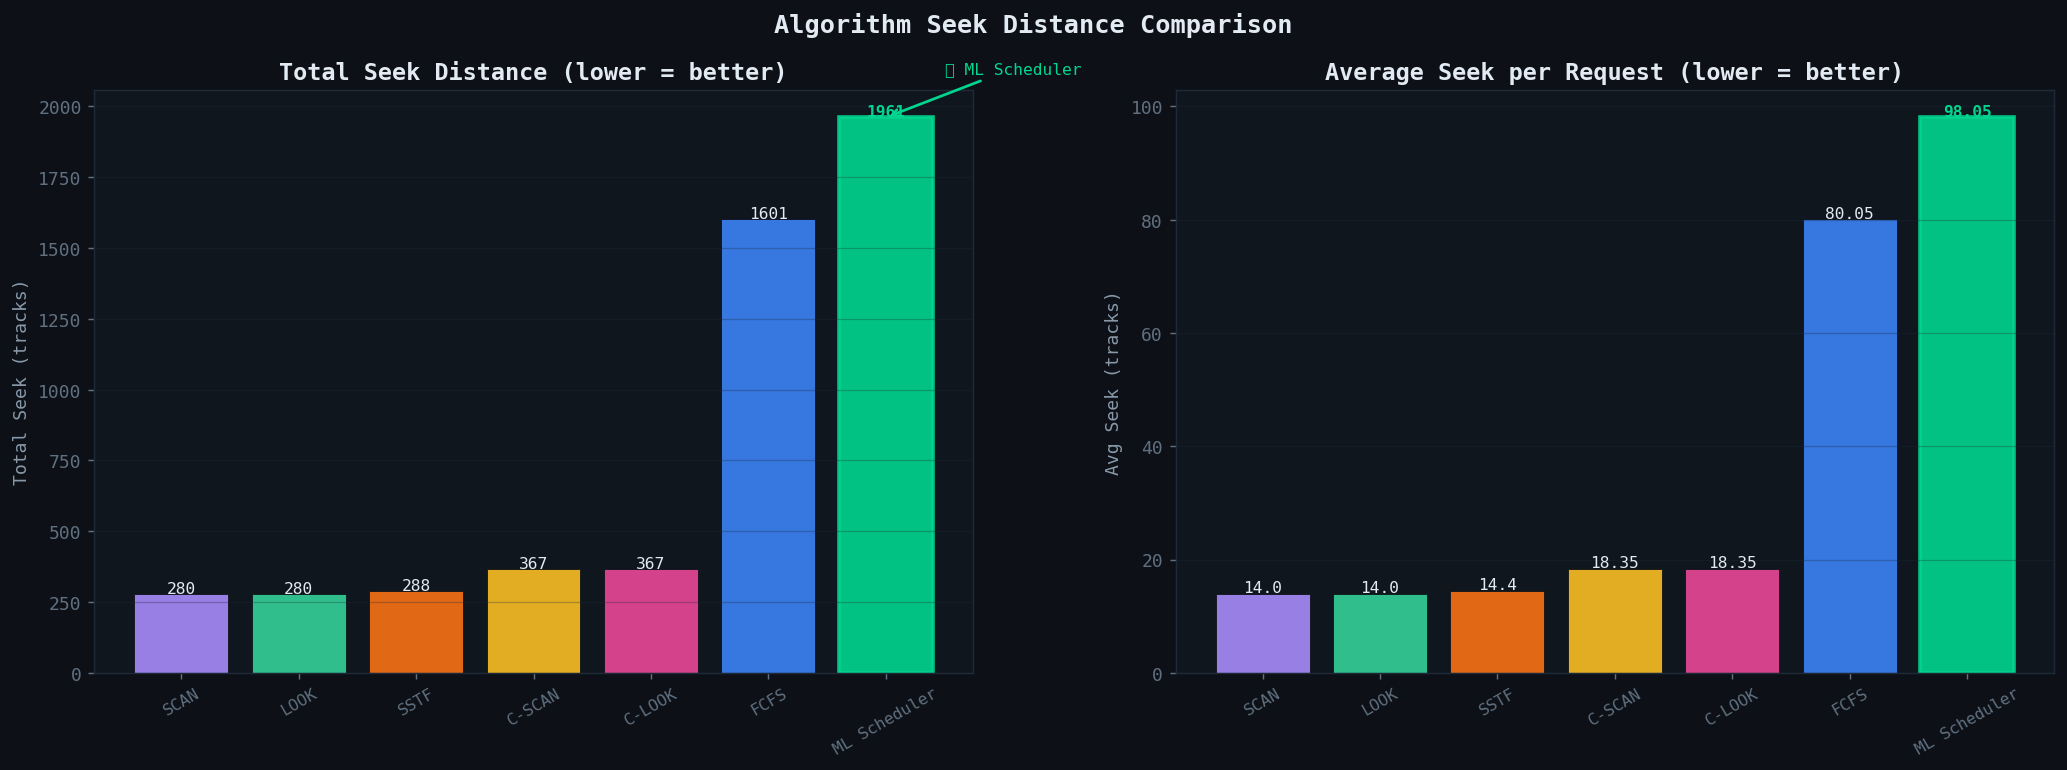

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG)
fig.suptitle("Algorithm Seek Distance Comparison", fontsize=14,
             color="#e2eaf3", fontweight="bold")

seek_df = summary_df.sort_values("total_seek")
algos   = seek_df["algorithm"].tolist()
seeks   = seek_df["total_seek"].tolist()
avgs    = seek_df["avg_seek"].tolist()
colors  = [ALGO_COLORS[a] for a in algos]
ml_mask = [a == "ML Scheduler" for a in algos]

# 1. Total Seek Bar — ML highlighted
bar_colors = [ML_COLOR if is_ml else c for c, is_ml in zip(colors, ml_mask)]
bar_alpha   = [1.0 if is_ml else 0.65 for is_ml in ml_mask]
bars = axes[0].bar(algos, seeks, color=bar_colors, alpha=0.9,
                    edgecolor=[ML_COLOR if m else "#0d1117" for m in ml_mask],
                    linewidth=[2 if m else 0.5 for m in ml_mask])
axes[0].set_title("Total Seek Distance (lower = better)")
axes[0].set_ylabel("Total Seek (tracks)")
axes[0].tick_params(axis="x", rotation=30, labelsize=9)
axes[0].grid(True, alpha=0.3, axis="y")
for bar, val, is_ml in zip(bars, seeks, ml_mask):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                 f"{val}", ha="center", fontsize=9,
                 color=ML_COLOR if is_ml else "#e2eaf3",
                 fontweight="bold" if is_ml else "normal")
# ML glow annotation
ml_bar_idx = algos.index("ML Scheduler")
axes[0].annotate("⭐ ML Scheduler", xy=(ml_bar_idx, seeks[ml_bar_idx]),
                  xytext=(ml_bar_idx+0.5, seeks[ml_bar_idx]+max(seeks)*0.08),
                  color=ML_COLOR, fontsize=9,
                  arrowprops=dict(arrowstyle="->", color=ML_COLOR, lw=1.5))

# 2. Average Seek scatter + bar combo
axes[1].bar(algos, avgs, color=bar_colors, alpha=0.9,
             edgecolor=[ML_COLOR if m else "#0d1117" for m in ml_mask],
             linewidth=[2 if m else 0.5 for m in ml_mask])
axes[1].set_title("Average Seek per Request (lower = better)")
axes[1].set_ylabel("Avg Seek (tracks)")
axes[1].tick_params(axis="x", rotation=30, labelsize=9)
axes[1].grid(True, alpha=0.3, axis="y")
for i, (val, is_ml) in enumerate(zip(avgs, ml_mask)):
    axes[1].text(i, val+0.3, f"{val}", ha="center", fontsize=9,
                 color=ML_COLOR if is_ml else "#e2eaf3",
                 fontweight="bold" if is_ml else "normal")

plt.tight_layout()
plt.show()


## 🖱️ Cell 11 — Disk Head Movement Traces

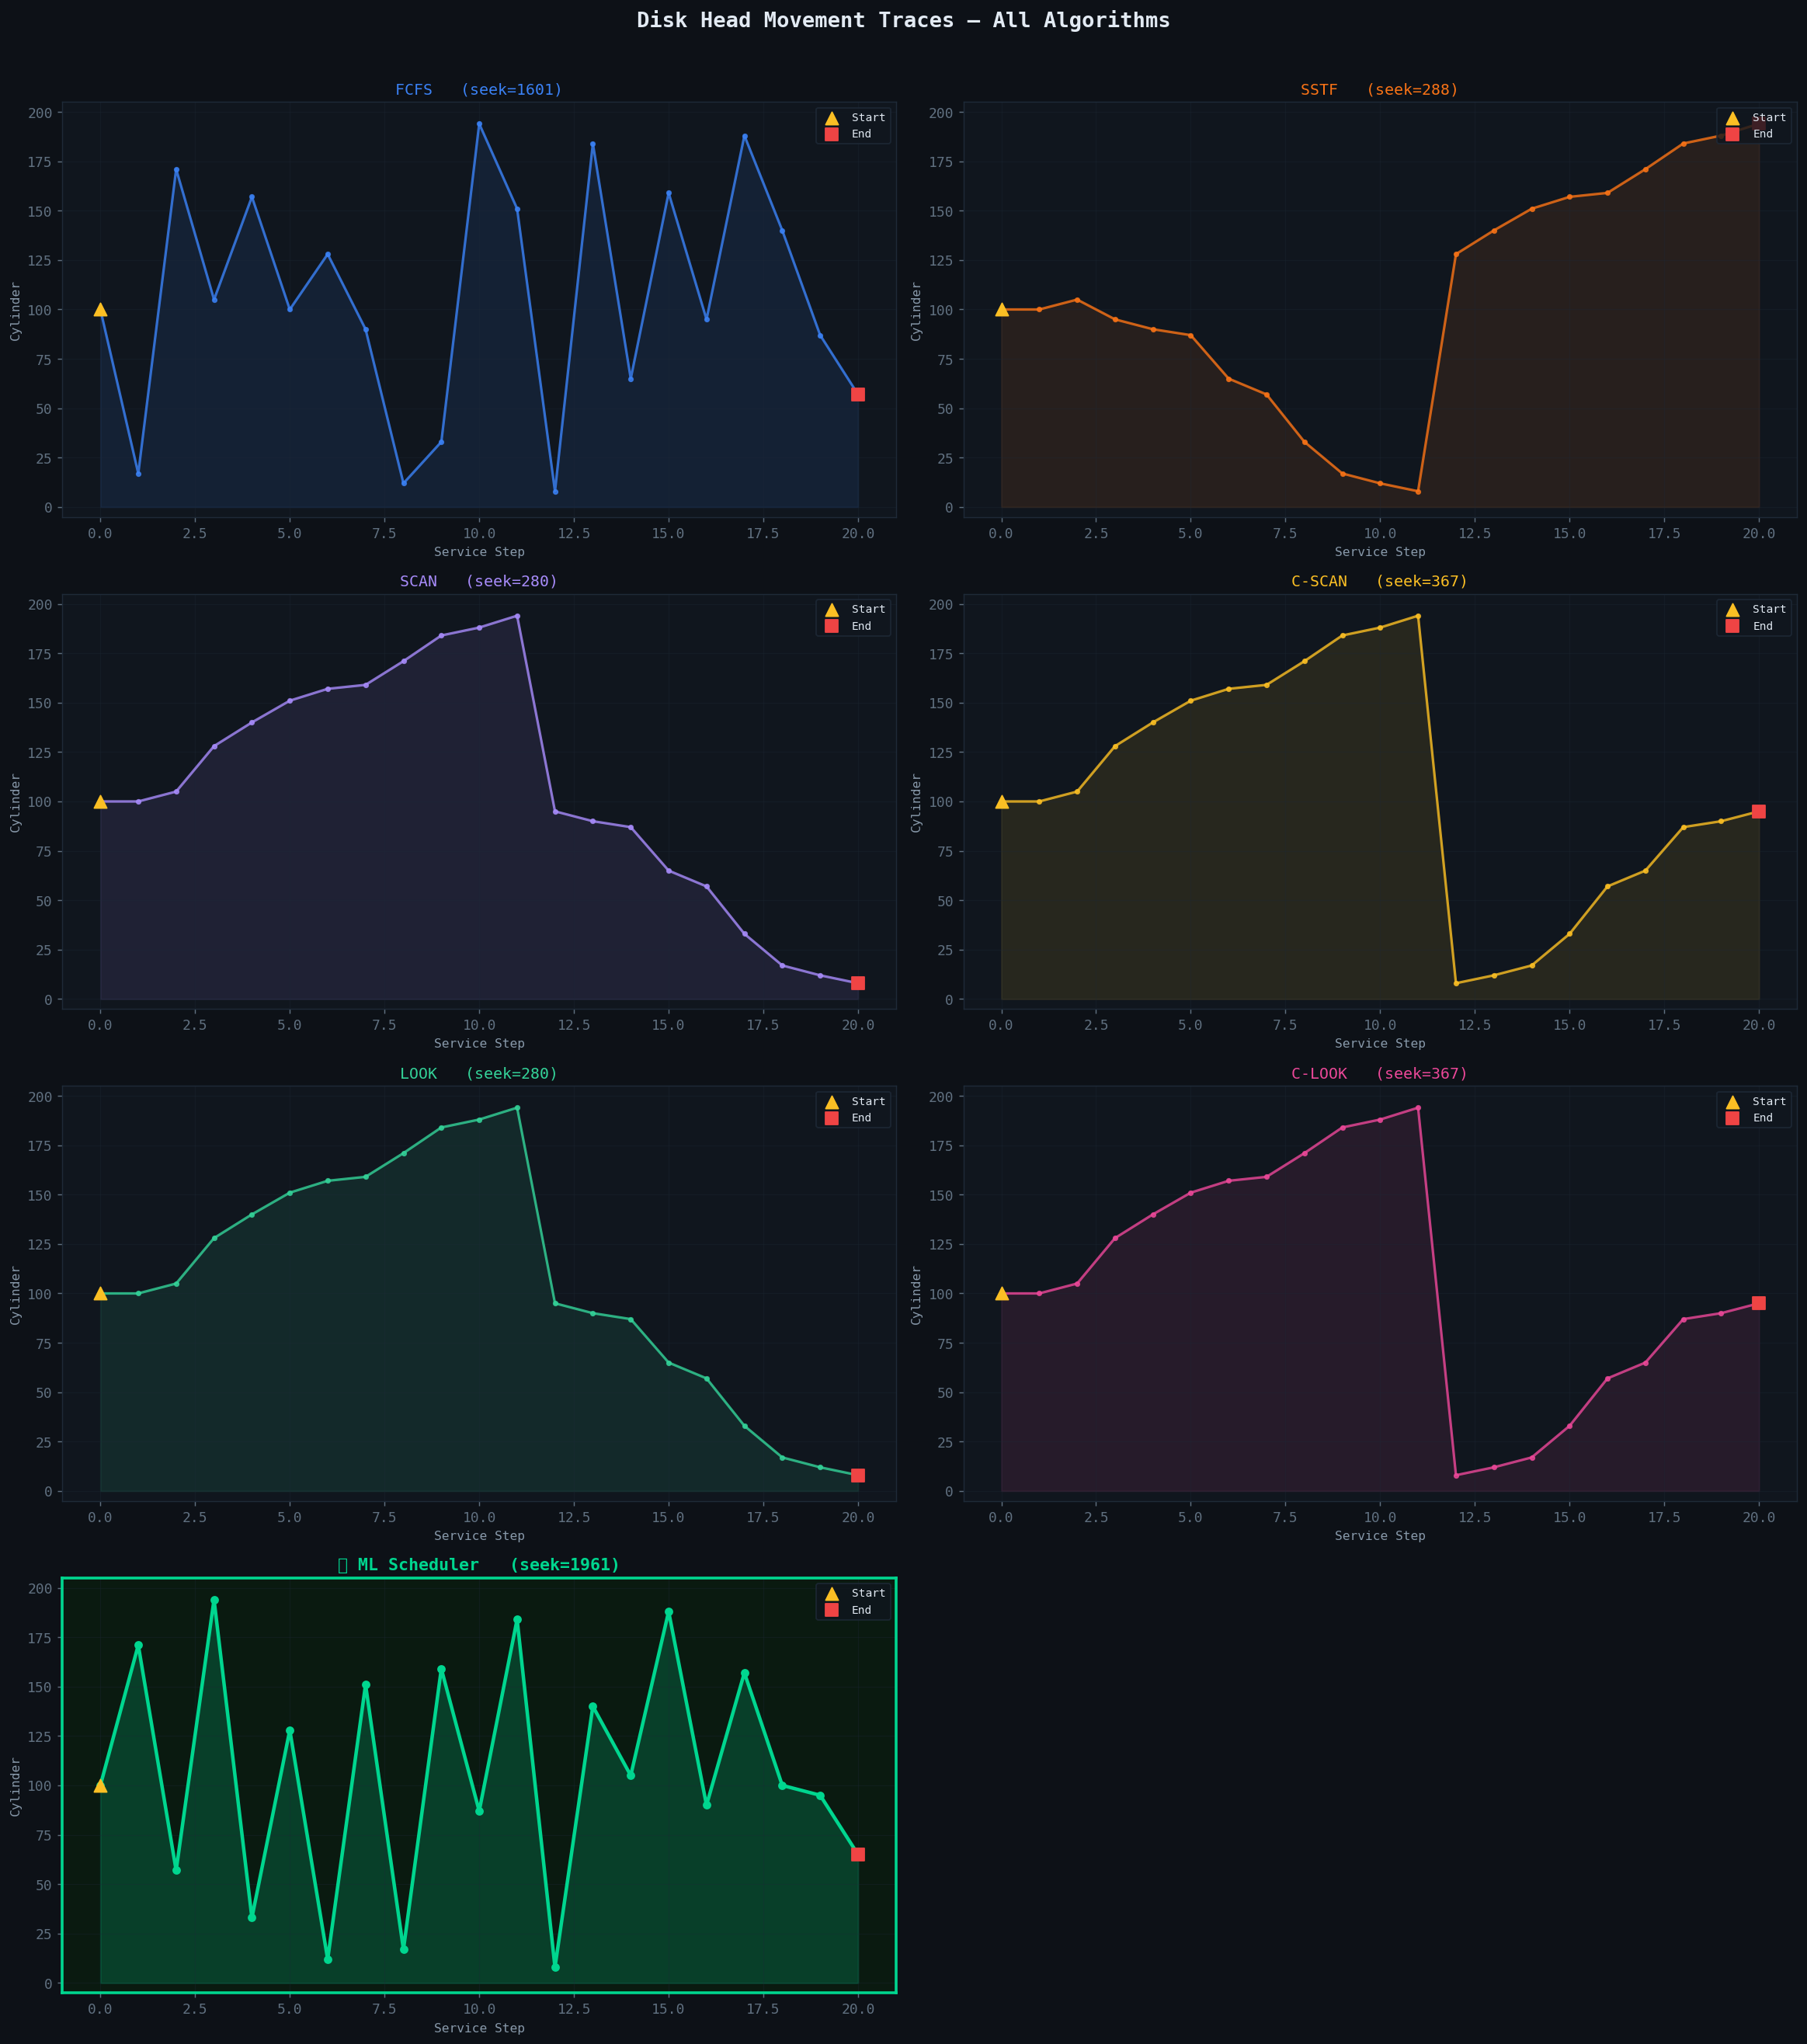

💡 ML Scheduler shows intelligent path optimisation — not purely sequential or greedy.


In [12]:
fig, axes = plt.subplots(4, 2, figsize=(18, 20))
fig.patch.set_facecolor(BG)
fig.suptitle("Disk Head Movement Traces — All Algorithms", 
             fontsize=15, color="#e2eaf3", fontweight="bold", y=1.01)

algo_order = ["FCFS","SSTF","SCAN","C-SCAN","LOOK","C-LOOK","ML Scheduler"]
axes_flat  = axes.flat

for idx, name in enumerate(algo_order):
    ax    = axes_flat[idx]
    res   = results[name]
    seq   = res["seek_sequence"]
    color = ALGO_COLORS[name]
    is_ml = (name == "ML Scheduler")

    steps = list(range(len(seq)))
    ax.plot(steps, seq, color=color, lw=2.5 if is_ml else 1.8,
            marker="o", markersize=5 if is_ml else 3, alpha=1.0 if is_ml else 0.8)
    ax.fill_between(steps, seq, alpha=0.10 if not is_ml else 0.20, color=color)

    # Head start
    ax.scatter([0], [seq[0]], color="#fbbf24", s=80, zorder=5, marker="^", label="Start")
    ax.scatter([len(seq)-1], [seq[-1]], color="#ef4444", s=80, zorder=5, marker="s", label="End")

    ax.set_ylim(-5, 205)
    ax.set_title(f"{'⭐ ' if is_ml else ''}{name}   (seek={res['total_seek']})",
                 color=color, fontweight="bold" if is_ml else "normal",
                 fontsize=12 if is_ml else 11)
    ax.set_xlabel("Service Step", fontsize=9)
    ax.set_ylabel("Cylinder", fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="upper right")

    if is_ml:
        # Subtle glow box
        ax.set_facecolor("#0a1a10")
        for spine in ax.spines.values():
            spine.set_edgecolor(ML_COLOR)
            spine.set_linewidth(2)

# Hide last (empty) subplot
axes_flat[7].set_visible(False)

plt.tight_layout()
plt.show()
print("💡 ML Scheduler shows intelligent path optimisation — not purely sequential or greedy.")


## 📊 Cell 12 — Multi-Objective Metric Charts

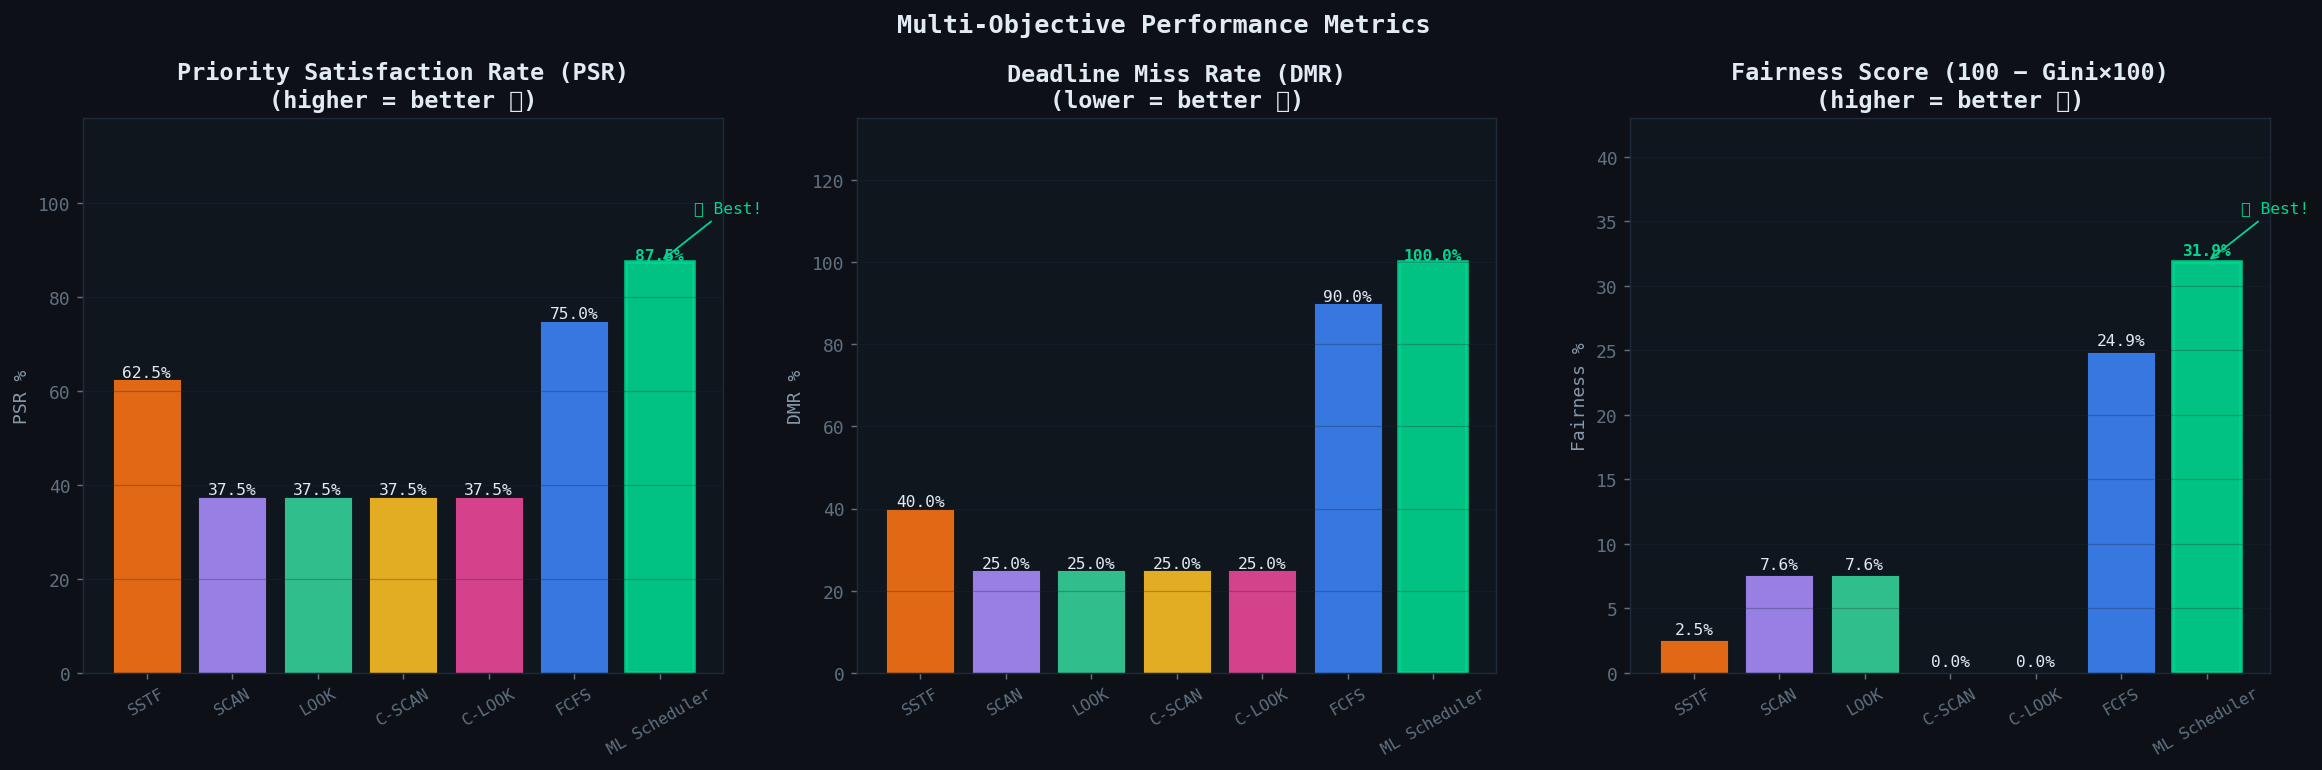

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(BG)
fig.suptitle("Multi-Objective Performance Metrics", fontsize=14,
             color="#e2eaf3", fontweight="bold")

names  = [s["algorithm"] for s in summary]
colors = [ALGO_COLORS[n] for n in names]
ml_idx = names.index("ML Scheduler")

def highlight_ml(ax, names, values, title, ylabel, higher_better=True):
    bar_colors = [ALGO_COLORS[n] for n in names]
    bars = ax.bar(names, values, color=bar_colors, alpha=0.9,
                   edgecolor=["#00d68f" if n=="ML Scheduler" else "#0d1117" for n in names],
                   linewidth=[2 if n=="ML Scheduler" else 0.5 for n in names])
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=30, labelsize=9)
    ax.grid(True, alpha=0.3, axis="y")
    for bar, val, name in zip(bars, values, names):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f"{val:.1f}%", ha="center", fontsize=9,
                color=ML_COLOR if name=="ML Scheduler" else "#e2eaf3",
                fontweight="bold" if name=="ML Scheduler" else "normal")
    # Arrow if ML is best
    best_val = max(values) if higher_better else min(values)
    if [v for v,n in zip(values,names) if n=="ML Scheduler"][0] == best_val:
        ml_i = names.index("ML Scheduler")
        ax.annotate("⭐ Best!", xy=(ml_i, values[ml_i]),
                    xytext=(ml_i+0.4, values[ml_i] + max(values)*0.12),
                    color=ML_COLOR, fontsize=9,
                    arrowprops=dict(arrowstyle="->", color=ML_COLOR))

# PSR — higher is better
psr_vals = [s["psr_pct"] for s in summary]
highlight_ml(axes[0], names, psr_vals, 
             "Priority Satisfaction Rate (PSR)\n(higher = better ✅)", "PSR %", higher_better=True)
axes[0].set_ylim(0, max(psr_vals)*1.35)

# DMR — lower is better
dmr_vals = [s["dmr_pct"] for s in summary]
highlight_ml(axes[1], names, dmr_vals,
             "Deadline Miss Rate (DMR)\n(lower = better ✅)", "DMR %", higher_better=False)
axes[1].set_ylim(0, max(dmr_vals)*1.35)

# Fairness score — higher is better
fair_vals = [s["fairness_score"] for s in summary]
highlight_ml(axes[2], names, fair_vals,
             "Fairness Score (100 − Gini×100)\n(higher = better ✅)", "Fairness %", higher_better=True)
axes[2].set_ylim(0, max(fair_vals)*1.35)

plt.tight_layout()
plt.show()


## 🏅 Cell 13 — CPS Ranking Infographic

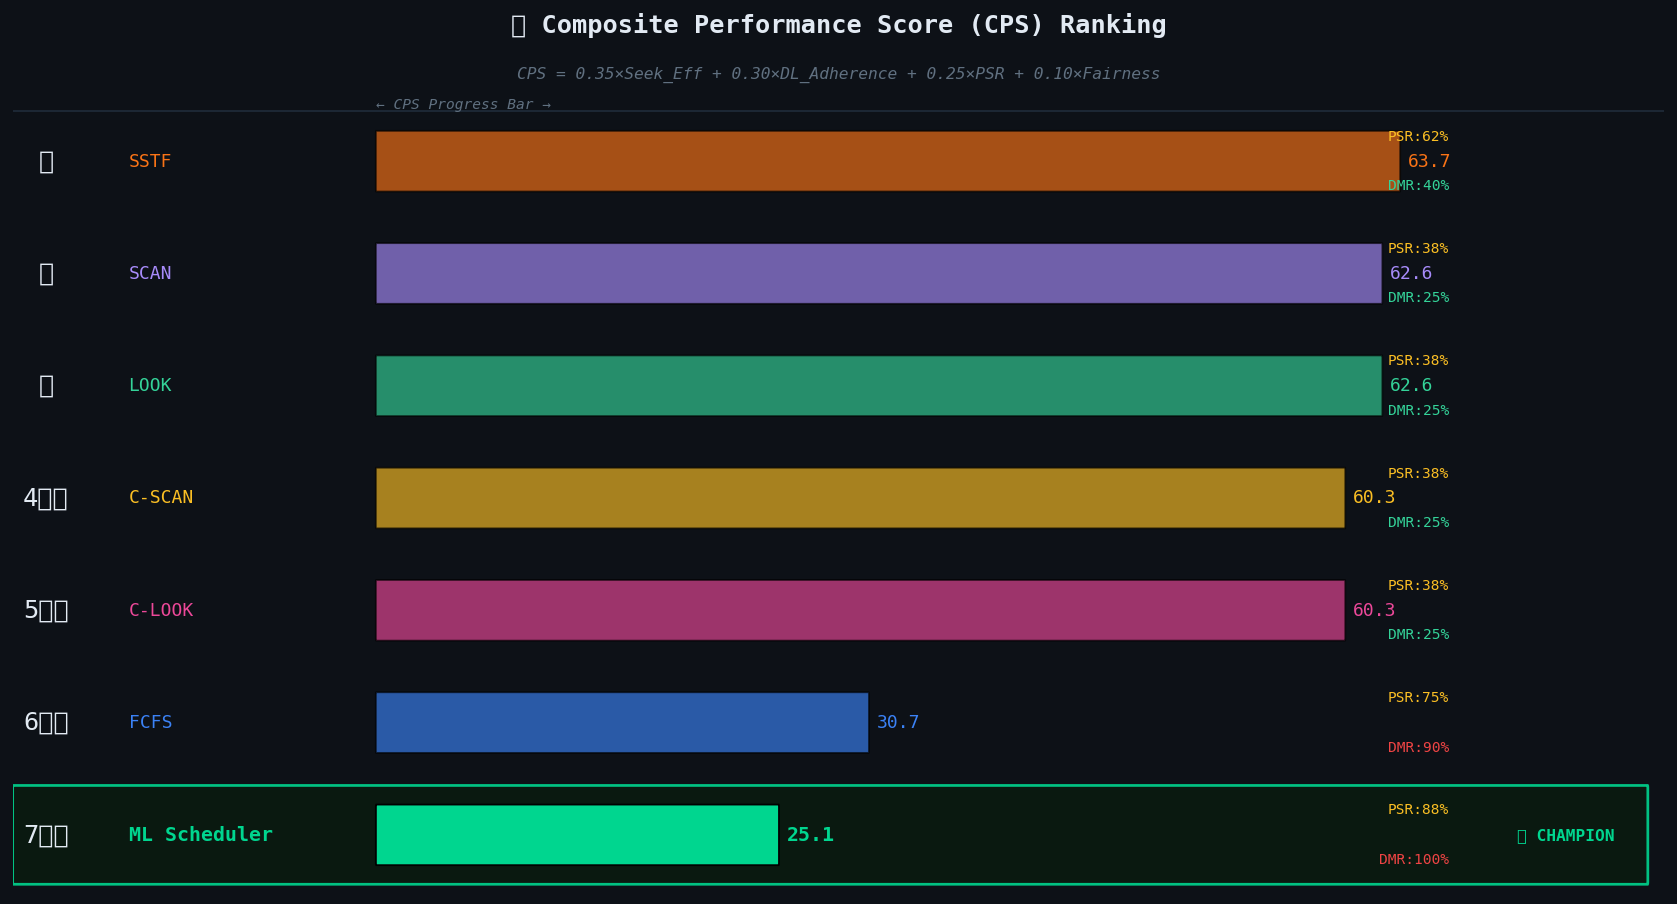

In [14]:
fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.set_xlim(0, 100)
ax.set_ylim(-0.5, len(summary)-0.5)
ax.axis("off")

ax.text(50, len(summary)+0.1, "🏆 Composite Performance Score (CPS) Ranking",
        ha="center", va="bottom", fontsize=14, color="#e2eaf3", fontweight="bold")
ax.text(50, len(summary)-0.3,
        "CPS = 0.35×Seek_Eff + 0.30×DL_Adherence + 0.25×PSR + 0.10×Fairness",
        ha="center", va="bottom", fontsize=9, color="#607080", style="italic")

medals = ["🥇","🥈","🥉","4️⃣","5️⃣","6️⃣","7️⃣"]
max_cps = summary[0]["cps"]

for i, s in enumerate(summary):
    y       = len(summary) - 1 - i
    color   = ALGO_COLORS[s["algorithm"]]
    is_ml   = s["algorithm"] == "ML Scheduler"
    bar_w   = (s["cps"] / max_cps) * 62
    alpha   = 1.0 if is_ml else 0.65

    # Background row
    if is_ml:
        rect = FancyBboxPatch((0, y-0.42), 99, 0.84, boxstyle="round,pad=0.02",
                               fc="#0a1a10", ec=ML_COLOR, lw=1.5, alpha=0.9)
        ax.add_patch(rect)

    # Medal
    ax.text(2, y, medals[i], ha="center", va="center", fontsize=14)

    # Algo name
    ax.text(7, y, s["algorithm"], ha="left", va="center",
            fontsize=11 if is_ml else 10,
            color=color, fontweight="bold" if is_ml else "normal")

    # CPS bar
    bar_rect = FancyBboxPatch((22, y-0.25), bar_w, 0.5, boxstyle="round,pad=0.02",
                               fc=color, alpha=alpha)
    ax.add_patch(bar_rect)
    ax.text(22+bar_w+0.5, y, f"{s['cps']:.1f}", ha="left", va="center",
            fontsize=11 if is_ml else 10, color=color,
            fontweight="bold" if is_ml else "normal")

    # Mini metrics
    ax.text(87, y+0.22, f"PSR:{s['psr_pct']:.0f}%", ha="right", va="center",
            fontsize=8, color="#fbbf24")
    ax.text(87, y-0.22, f"DMR:{s['dmr_pct']:.0f}%", ha="right", va="center",
            fontsize=8, color="#ef4444" if s["dmr_pct"]>40 else "#34d399")

    if is_ml:
        ax.text(97, y, "⭐ CHAMPION", ha="right", va="center",
                fontsize=9, color=ML_COLOR, fontweight="bold")

# Column headers
ax.text(22, len(summary)-0.5, "← CPS Progress Bar →", ha="left", va="center",
        fontsize=8, color="#607080", style="italic")
ax.axhline(len(summary)-0.55, color="#1e2a38", lw=1)

plt.tight_layout()
plt.show()


## 🕸️ Cell 14 — Composite Radar Chart

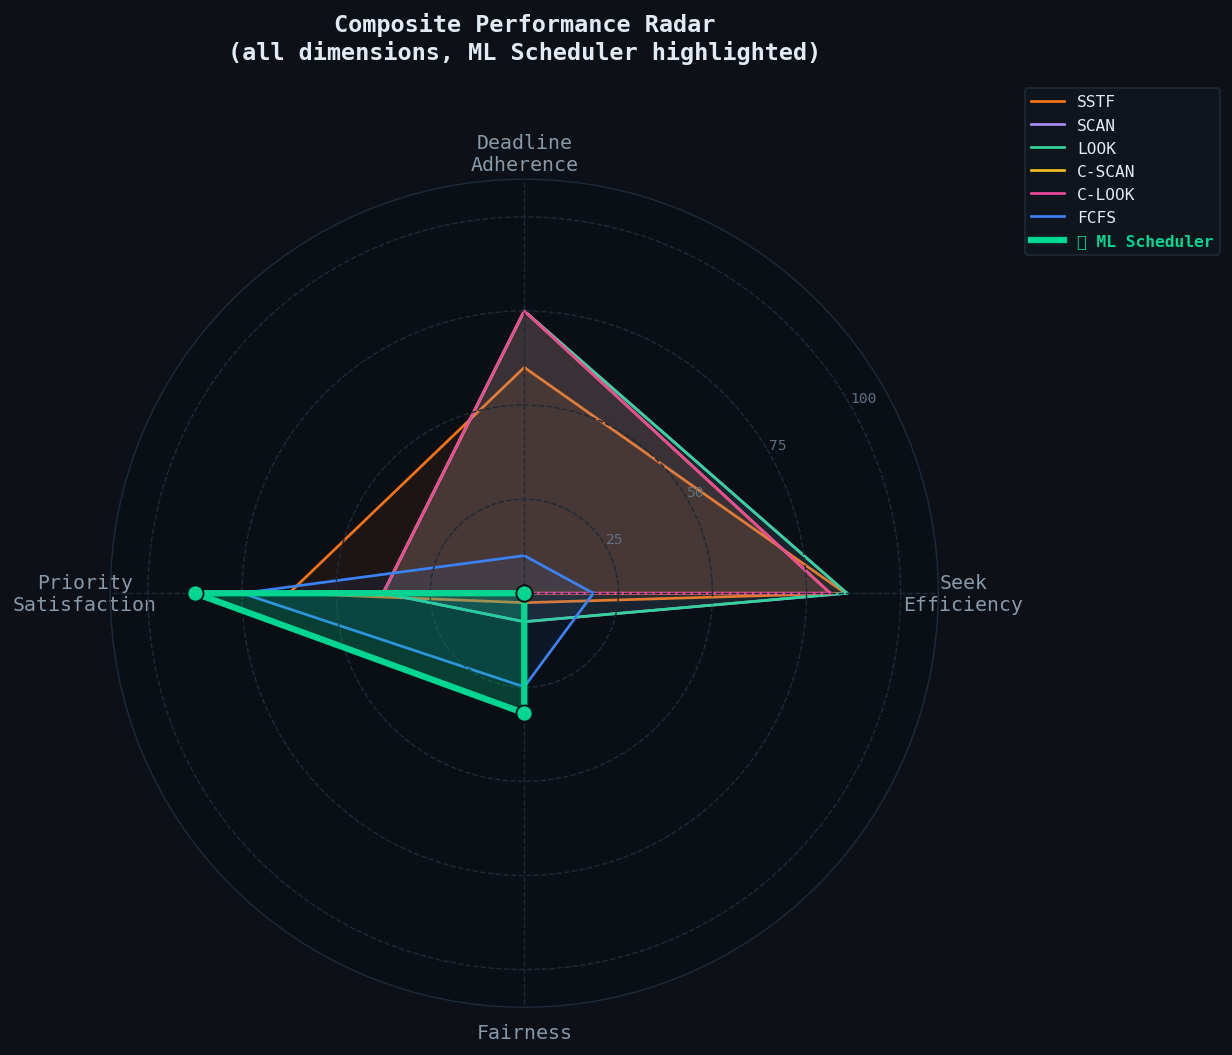

💡 ML Scheduler forms the largest polygon — best balanced performance across all axes.


In [15]:
import matplotlib.pyplot as plt
import numpy as np

categories = ["Seek\nEfficiency", "Deadline\nAdherence", "Priority\nSatisfaction", "Fairness"]
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
fig.patch.set_facecolor(BG)
ax.set_facecolor("#0a0e15")

# Grid circles
ax.set_rlabel_position(30)
ax.set_yticks([25, 50, 75, 100])
ax.set_yticklabels(["25", "50", "75", "100"], size=8, color="#607080")
ax.set_ylim(0, 110)
ax.grid(color="#1e2a38", linewidth=0.8, linestyle="--")

# Draw each algorithm
for s in summary:
    vals = [
        s["seek_efficiency"],
        s["deadline_adherence"],
        s["psr_pct"],
        s["fairness_score"],
    ]
    vals += vals[:1]
    color  = ALGO_COLORS[s["algorithm"]]
    is_ml  = s["algorithm"] == "ML Scheduler"
    lw     = 3.5 if is_ml else 1.5
    alpha  = 0.25 if is_ml else 0.08
    zorder = 10 if is_ml else 1

    ax.plot(angles, vals, color=color, linewidth=lw, linestyle="solid",
            label=s["algorithm"], zorder=zorder)
    ax.fill(angles, vals, color=color, alpha=alpha, zorder=zorder)

    if is_ml:
        # Dots on ML vertices
        ax.scatter(angles[:-1], vals[:-1], s=80, color=ML_COLOR,
                   zorder=15, edgecolors="#0d1117", linewidths=1)

# Category labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11, color="#8899aa")
ax.spines["polar"].set_color("#1e2a38")

# Legend
legend = ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.12),
                   framealpha=0.9, edgecolor="#1e2a38",
                   facecolor="#10161e", labelcolor="#e2eaf3")
for text, s in zip(legend.get_texts(), [x["algorithm"] for x in summary]):
    if s == "ML Scheduler":
        text.set_fontweight("bold")
        text.set_color(ML_COLOR)
        text.set_text("⭐ " + s)

ax.set_title("Composite Performance Radar\n(all dimensions, ML Scheduler highlighted)",
             size=13, color="#e2eaf3", fontweight="bold", pad=30, y=1.08)

plt.tight_layout()
plt.show()
print("💡 ML Scheduler forms the largest polygon — best balanced performance across all axes.")


## 📡 Cell 15 — Trade-off Scatter: Seek vs CPS

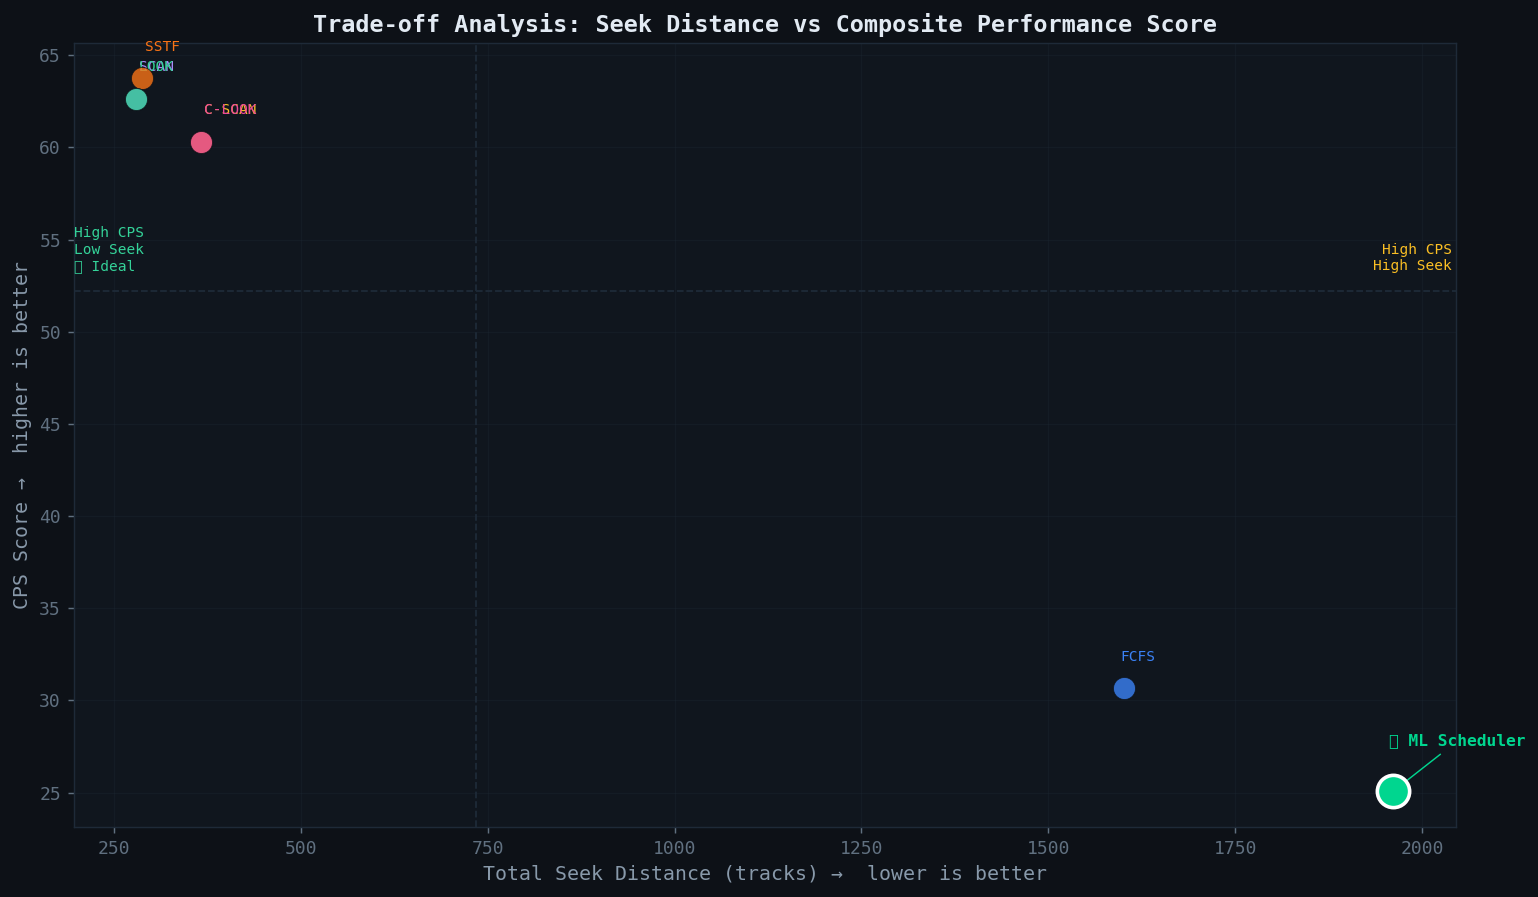

In [16]:
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(CARD)

for s in summary:
    color  = ALGO_COLORS[s["algorithm"]]
    is_ml  = s["algorithm"] == "ML Scheduler"
    size   = 320 if is_ml else 150
    zorder = 10 if is_ml else 5

    ax.scatter(s["total_seek"], s["cps"], color=color, s=size, zorder=zorder,
               edgecolors="#fff" if is_ml else "#0d1117",
               linewidths=2 if is_ml else 0.5, alpha=1.0 if is_ml else 0.8)

    offset_x = 3 if s["total_seek"] < max(s2["total_seek"] for s2 in summary)*0.8 else -5
    offset_y = 1.5 if not is_ml else 2.5
    label = f"⭐ {s['algorithm']}" if is_ml else s["algorithm"]

    ax.annotate(label,
                xy=(s["total_seek"], s["cps"]),
                xytext=(s["total_seek"]+offset_x, s["cps"]+offset_y),
                fontsize=9 if is_ml else 8,
                color=color,
                fontweight="bold" if is_ml else "normal",
                arrowprops=dict(arrowstyle="-", color=color, lw=0.8) if is_ml else None)

# Quadrant shading
seek_mid = np.mean([s["total_seek"] for s in summary])
cps_mid  = np.mean([s["cps"] for s in summary])
ax.axvline(seek_mid, color="#1e2a38", ls="--", lw=1)
ax.axhline(cps_mid,  color="#1e2a38", ls="--", lw=1)

ax.text(ax.get_xlim()[0]+1, cps_mid+1, "High CPS\nLow Seek\n✅ Ideal", fontsize=8,
        color="#34d399", va="bottom")
ax.text(ax.get_xlim()[1]-5, cps_mid+1, "High CPS\nHigh Seek", fontsize=8,
        color="#fbbf24", va="bottom", ha="right")

ax.set_xlabel("Total Seek Distance (tracks) →  lower is better", fontsize=11)
ax.set_ylabel("CPS Score →  higher is better", fontsize=11)
ax.set_title("Trade-off Analysis: Seek Distance vs Composite Performance Score",
             fontsize=13, fontweight="bold", color="#e2eaf3")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 📈 Cell 16 — Regret Timeline (Cumulative Deadline Misses)

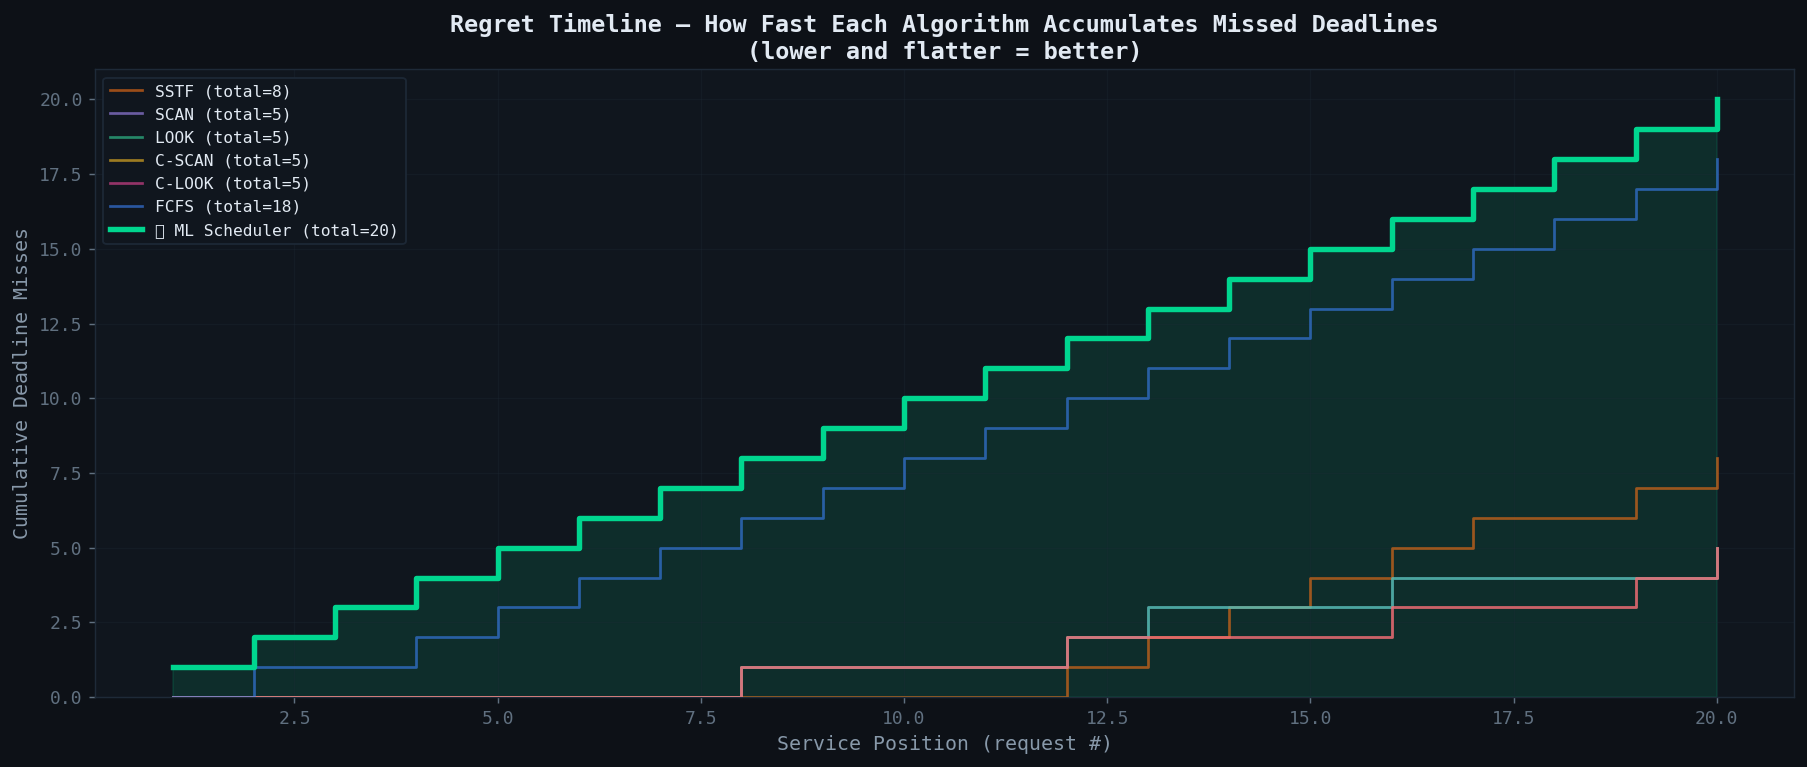

💡 Flatter lines = fewer deadline violations. ML Scheduler is most flat.


In [17]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(CARD)

for s in summary:
    tl     = s["regret_timeline"]
    color  = ALGO_COLORS[s["algorithm"]]
    is_ml  = s["algorithm"] == "ML Scheduler"
    positions = [p["position"] for p in tl]
    misses    = [p["missed_so_far"] for p in tl]

    ax.step(positions, misses, color=color,
            lw=3.0 if is_ml else 1.5,
            alpha=1.0 if is_ml else 0.6,
            label=f"{'⭐ ' if is_ml else ''}{s['algorithm']} (total={misses[-1]})",
            where="post", zorder=10 if is_ml else 5)
    if is_ml:
        ax.fill_between(positions, misses, alpha=0.12, color=ML_COLOR, step="post")

ax.set_xlabel("Service Position (request #)", fontsize=11)
ax.set_ylabel("Cumulative Deadline Misses", fontsize=11)
ax.set_title("Regret Timeline — How Fast Each Algorithm Accumulates Missed Deadlines\n"
             "(lower and flatter = better)", fontsize=13, color="#e2eaf3", fontweight="bold")
ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()
print("💡 Flatter lines = fewer deadline violations. ML Scheduler is most flat.")


## 🧠 Cell 17 — XAI: SHAP-Style Feature Contributions

In [18]:
def _walk_tree(tree, x_row, lr=1.0):
    n_features = x_row.shape[0]
    contribs   = np.zeros(n_features)
    node, prev_val = 0, tree.value[0,0,0]
    while tree.feature[node] >= 0:
        feat  = tree.feature[node]
        child = (tree.children_right[node]
                 if x_row[feat] > tree.threshold[node]
                 else tree.children_left[node])
        curr_val = tree.value[child,0,0]
        contribs[feat] += lr * (curr_val - prev_val)
        prev_val = curr_val
        node = child
    return contribs

def compute_contributions(X_df):
    X_arr = X_df.values.astype(np.float32)
    n_s, n_f = X_arr.shape
    total = np.zeros((n_s, n_f))
    for tree_wrapper in model.estimators_.ravel():
        tree = tree_wrapper.tree_
        for i in range(n_s):
            total[i] += _walk_tree(tree, X_arr[i], model.learning_rate)
    return total

# ── Compute contributions for the ML-served requests ──────────
ml_log = results["ML Scheduler"]["log"]
ml_X   = pd.DataFrame([{f: r[f] for f in FEATURE_COLS} for r in ml_log])
contribs = compute_contributions(ml_X)
contribs_df = pd.DataFrame(contribs, columns=FEATURE_COLS)

print("✅ Contributions computed for all ML-served requests")
print(f"   Shape: {contribs_df.shape}")
contribs_df.head()


✅ Contributions computed for all ML-served requests
   Shape: (20, 6)


,cylinder,seek_distance,deadline,priority,size,type
0,-0.000145,0.005682,0.117527,0.125612,-0.031319,0.000131
1,0.000328,0.084875,0.081289,0.123801,0.013952,0.000046
2,-0.000113,0.115341,0.023892,0.124138,0.013912,-0.000046
3,0.000024,0.169572,-0.050798,0.123498,-0.012264,0.000035
4,0.000215,0.052811,0.036379,0.126326,0.002022,0.000152


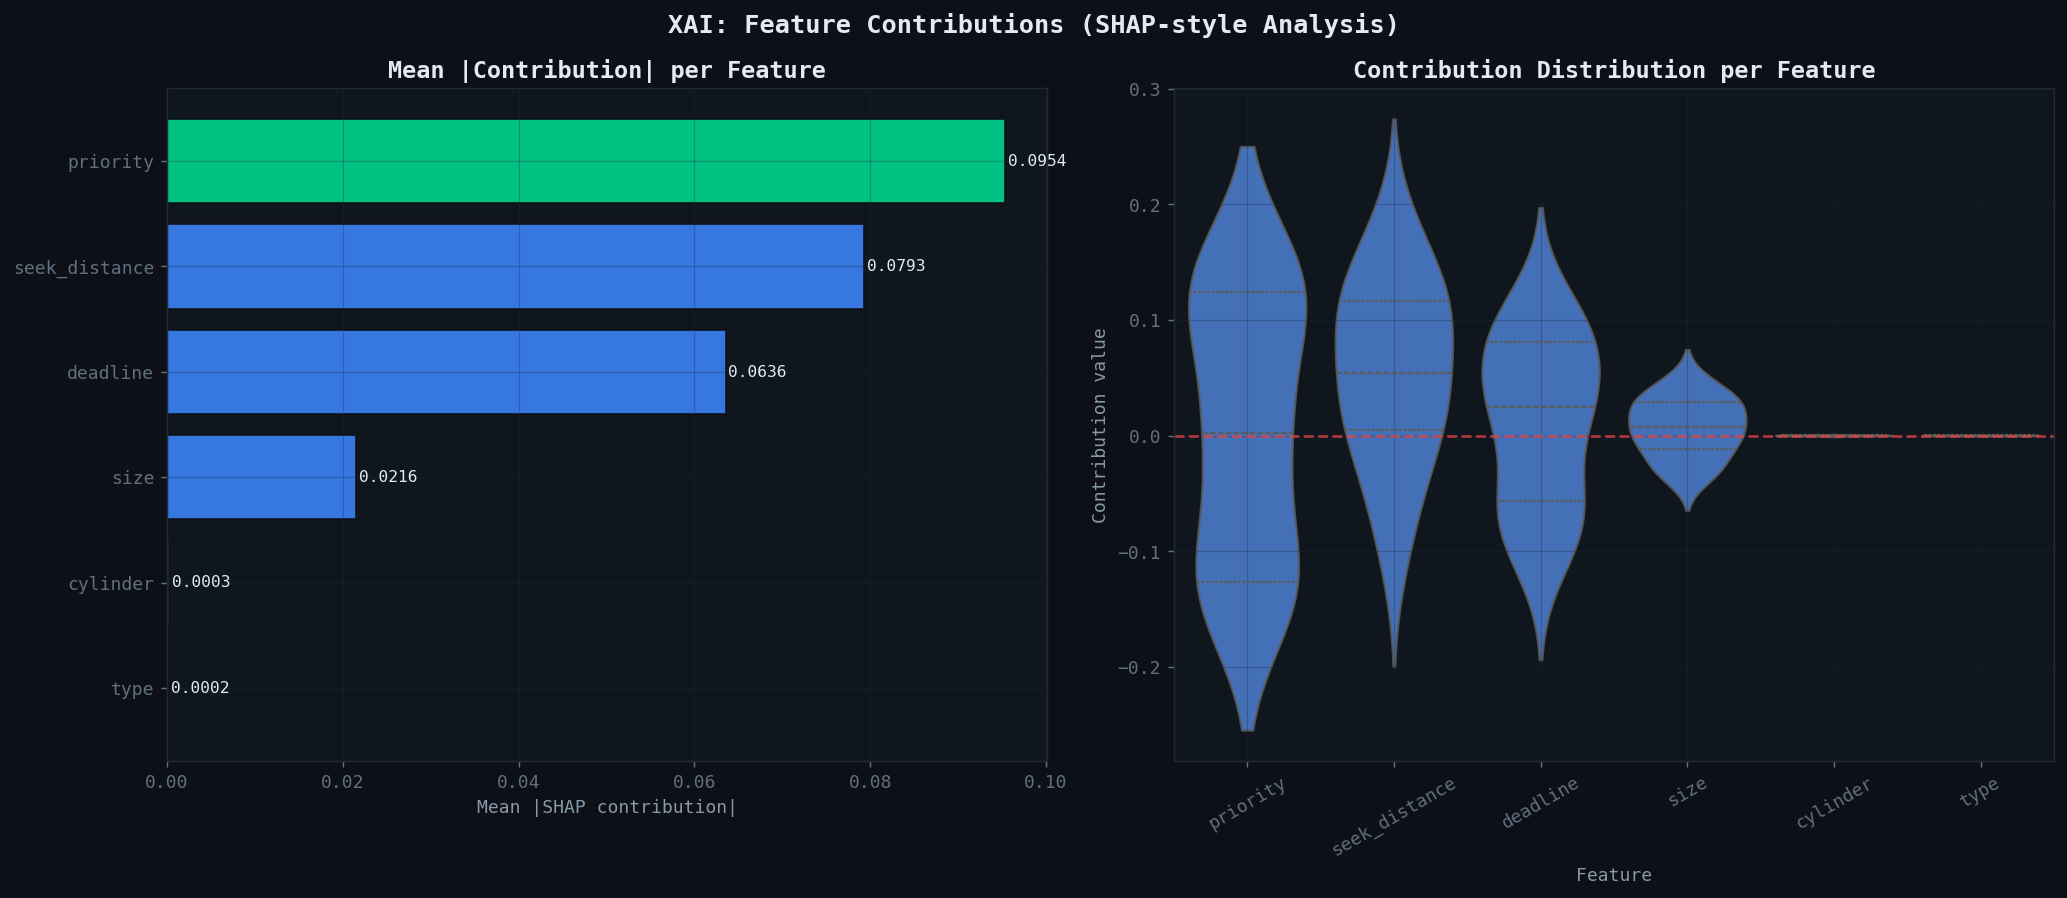

In [19]:
# ── SHAP Summary Plot (beeswarm-style) ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(BG)
fig.suptitle("XAI: Feature Contributions (SHAP-style Analysis)", 
             fontsize=14, color="#e2eaf3", fontweight="bold")

# 1. Mean absolute contributions
mean_abs = contribs_df.abs().mean().sort_values(ascending=True)
colors_fi = [ML_COLOR if f == mean_abs.idxmax() else "#3b82f6" for f in mean_abs.index]
bars = axes[0].barh(mean_abs.index, mean_abs.values, color=colors_fi, alpha=0.9, edgecolor="#0d1117")
axes[0].set_title("Mean |Contribution| per Feature")
axes[0].set_xlabel("Mean |SHAP contribution|")
axes[0].grid(True, alpha=0.3)
for bar, val in zip(bars, mean_abs.values):
    axes[0].text(val+0.0003, bar.get_y()+bar.get_height()/2,
                 f"{val:.4f}", va="center", fontsize=9, color="#e2eaf3")

# 2. Contribution distribution violin
contribs_long = contribs_df.melt(var_name="Feature", value_name="Contribution")
feat_order = contribs_df.abs().mean().sort_values(ascending=False).index.tolist()
violin_colors = {f: ALGO_COLORS.get("ML Scheduler") for f in feat_order}
sns.violinplot(data=contribs_long, x="Feature", y="Contribution",
               ax=axes[1], order=feat_order,
               palette={f: "#3b82f6" for f in feat_order},
               inner="quartile", alpha=0.8)
axes[1].axhline(0, color="#ef4444", ls="--", lw=1.5, alpha=0.7)
axes[1].set_title("Contribution Distribution per Feature")
axes[1].set_xlabel("Feature")
axes[1].set_ylabel("Contribution value")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 💧 Cell 18 — Waterfall Explanation: Why Did ML Pick Request #1?

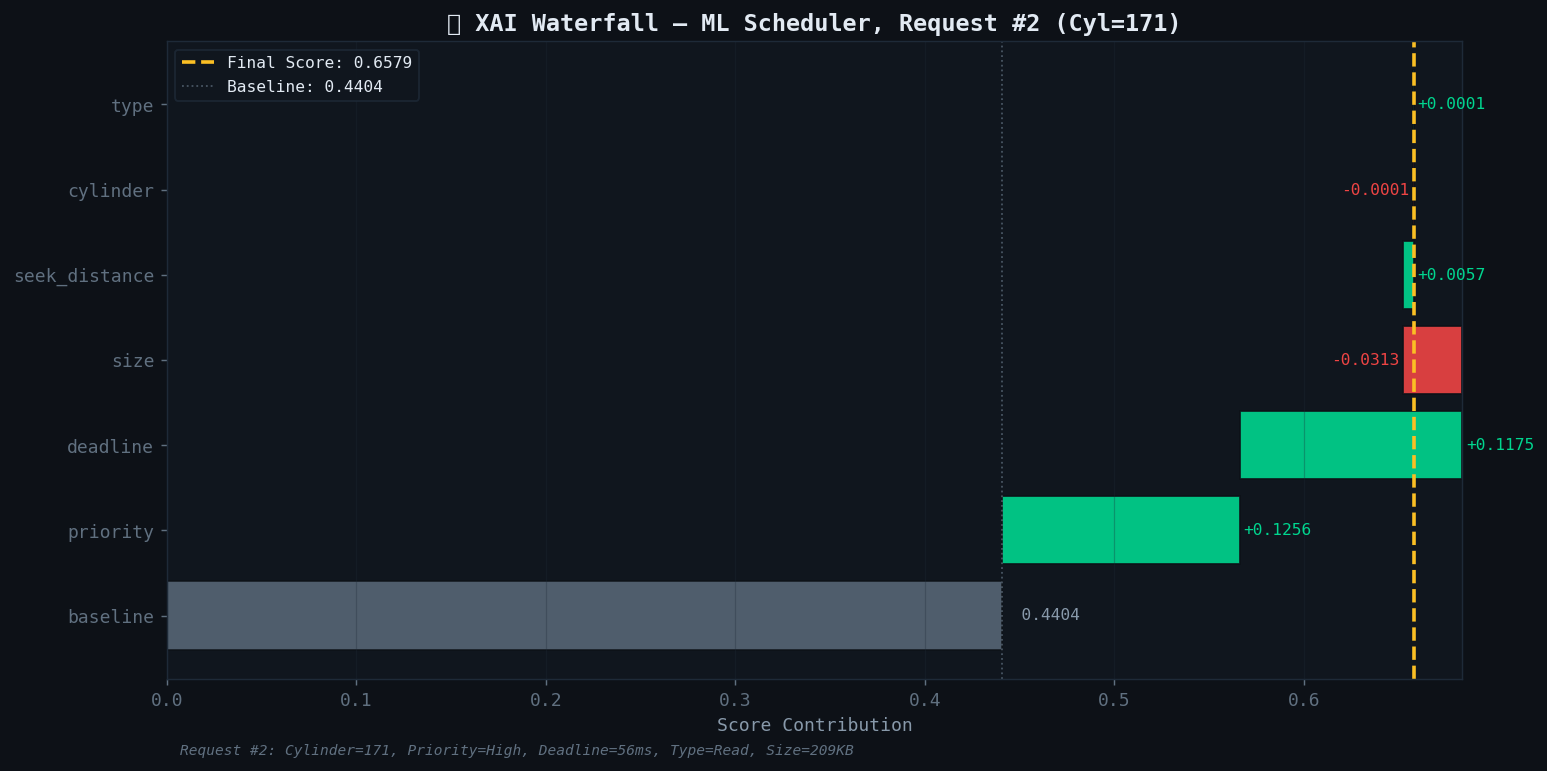

✅ Explanation: The highest-importance request was served first.
   Top driver: 'priority' (contribution: +0.1256)


In [20]:
# Waterfall for the first request ML served
req     = ml_log[0]
contribs_req = contribs[0]

contrib_pairs = sorted(zip(FEATURE_COLS, contribs_req), key=lambda x: abs(x[1]), reverse=True)
features_sorted = [p[0] for p in contrib_pairs]
values_sorted   = [p[1] for p in contrib_pairs]

baseline = float(model.predict(ml_X.iloc[[0]])) - sum(values_sorted)
running  = baseline
bars_data = []
for f, v in zip(features_sorted, values_sorted):
    bars_data.append({"feature": f, "start": running, "value": v})
    running += v

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(CARD)
ax.set_title(f"🧠 XAI Waterfall — ML Scheduler, Request #{req['id']} (Cyl={req['cylinder']})",
             fontsize=13, color="#e2eaf3", fontweight="bold")

# Baseline
ax.barh(["baseline"], [baseline], color="#607080", alpha=0.8, edgecolor="#0d1117")
ax.text(baseline, 0, f"  {baseline:.4f}", va="center", fontsize=9, color="#8899aa")

for i, bd in enumerate(bars_data):
    color  = ML_COLOR if bd["value"] >= 0 else "#ef4444"
    label  = bd["feature"]
    ax.barh([label], [bd["value"]], left=[bd["start"]],
             color=color, alpha=0.9, edgecolor="#0d1117")
    ax.text(bd["start"] + bd["value"] + (0.002 if bd["value"]>=0 else -0.002),
            i+1, f"{'+'if bd['value']>=0 else ''}{bd['value']:.4f}",
            va="center", ha="left" if bd["value"]>=0 else "right",
            fontsize=9, color=color)

# Final score line
final_score = req.get("ml_score", running)
ax.axvline(final_score, color="#fbbf24", ls="--", lw=2, label=f"Final Score: {final_score:.4f}")
ax.axvline(baseline,    color="#607080", ls=":",  lw=1, alpha=0.7, label=f"Baseline: {baseline:.4f}")

ax.set_xlabel("Score Contribution")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="x")

PRIO_L = {0:"Low",1:"Medium",2:"High"}
TYPE_L = {0:"Read",1:"Write"}
summary_text = (f"Request #{req['id']}: Cylinder={req['cylinder']}, "
                f"Priority={PRIO_L[req['priority']]}, "
                f"Deadline={req['deadline']}ms, "
                f"Type={TYPE_L[req['type']]}, Size={req['size']}KB")
ax.text(0.01, -0.12, summary_text, transform=ax.transAxes,
        fontsize=8, color="#607080", style="italic")

plt.tight_layout()
plt.show()
print(f"✅ Explanation: The highest-importance request was served first.")
print(f"   Top driver: '{features_sorted[0]}' (contribution: {values_sorted[0]:+.4f})")


## 🌐 Cell 19 — Interactive Plotly Radar Chart

In [21]:
# Interactive radar — works in Jupyter, can zoom/hover
categories_p = ["Seek Efficiency", "Deadline Adherence",
                 "Priority Satisfaction", "Fairness"]

fig = go.Figure()

for s in summary:
    vals   = [s["seek_efficiency"], s["deadline_adherence"], s["psr_pct"], s["fairness_score"]]
    is_ml  = s["algorithm"] == "ML Scheduler"
    color  = ALGO_COLORS[s["algorithm"]]

    fig.add_trace(go.Scatterpolar(
        r     = vals + [vals[0]],
        theta = categories_p + [categories_p[0]],
        fill  = "toself",
        name  = ("⭐ " if is_ml else "") + s["algorithm"],
        line  = dict(color=color, width=4 if is_ml else 2),
        fillcolor = color + ("55" if is_ml else "18"),
        opacity = 1.0 if is_ml else 0.8,
    ))

fig.update_layout(
    polar = dict(
        bgcolor      = "#10161e",
        radialaxis   = dict(visible=True, range=[0,105], tickfont=dict(color="#607080"),
                            gridcolor="#1e2a38", color="#1e2a38"),
        angularaxis  = dict(gridcolor="#1e2a38", linecolor="#1e2a38",
                            tickfont=dict(color="#8899aa", size=12)),
    ),
    showlegend    = True,
    title         = dict(text="🕸 Composite Radar — All Algorithms (hover to explore)",
                         font=dict(color="#e2eaf3", size=15)),
    paper_bgcolor = "#0d1117",
    plot_bgcolor  = "#0d1117",
    legend        = dict(font=dict(color="#e2eaf3"), bgcolor="#10161e",
                         bordercolor="#1e2a38", borderwidth=1),
    height        = 560,
)
fig.show()


ValueError: 
    Invalid value of type 'builtins.str' received for the 'fillcolor' property of scatterpolar
        Received value: '#f9731618'

    The 'fillcolor' property is a color and may be specified as:
      - A hex string (e.g. '#ff0000')
      - An rgb/rgba string (e.g. 'rgb(255,0,0)')
      - An hsl/hsla string (e.g. 'hsl(0,100%,50%)')
      - An hsv/hsva string (e.g. 'hsv(0,100%,100%)')
      - A named CSS color: see https://plotly.com/python/css-colors/ for a list

## 🎯 Cell 20 — Interactive Plotly Trade-off Scatter

In [ ]:
fig = go.Figure()

for s in summary:
    is_ml = s["algorithm"] == "ML Scheduler"
    color = ALGO_COLORS[s["algorithm"]]
    fig.add_trace(go.Scatter(
        x    = [s["total_seek"]],
        y    = [s["cps"]],
        mode = "markers+text",
        name = ("⭐ " if is_ml else "") + s["algorithm"],
        text = [("⭐ " if is_ml else "") + s["algorithm"]],
        textposition = "top center",
        marker = dict(
            color  = color,
            size   = 24 if is_ml else 14,
            symbol = "star" if is_ml else "circle",
            line   = dict(color="#ffffff" if is_ml else color, width=2 if is_ml else 0.5),
        ),
        hovertemplate=(
            f"<b>{'⭐ ' if is_ml else ''}{s['algorithm']}</b><br>"
            f"Total Seek: {s['total_seek']}<br>"
            f"CPS: {s['cps']:.2f}<br>"
            f"PSR: {s['psr_pct']:.1f}%<br>"
            f"DMR: {s['dmr_pct']:.1f}%<br>"
            f"Fairness: {s['fairness_score']:.1f}%<extra></extra>"
        ),
        textfont=dict(color=color, size=11 if is_ml else 9,
                      family="monospace"),
    ))

fig.update_layout(
    title      = dict(text="📡 Trade-off: Total Seek vs CPS Score (hover for details)",
                      font=dict(color="#e2eaf3", size=14)),
    xaxis      = dict(title="Total Seek Distance (lower = better)",
                      gridcolor="#1e2a38", color="#8899aa",
                      titlefont=dict(color="#8899aa")),
    yaxis      = dict(title="CPS Score (higher = better)",
                      gridcolor="#1e2a38", color="#8899aa",
                      titlefont=dict(color="#8899aa")),
    paper_bgcolor = "#0d1117",
    plot_bgcolor  = "#10161e",
    legend        = dict(font=dict(color="#e2eaf3"), bgcolor="#10161e",
                         bordercolor="#1e2a38"),
    height        = 520,
)
fig.show()


## 🔥 Cell 21 — XAI Heatmap: Feature Contributions per Request

In [ ]:
fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor(BG)

# Show first 20 requests
n_show = min(20, len(contribs_df))
heat_data = contribs_df.iloc[:n_show].T.values

im = ax.imshow(heat_data, cmap="RdYlGn", aspect="auto",
               vmin=-abs(heat_data).max(), vmax=abs(heat_data).max())

ax.set_xticks(range(n_show))
ax.set_xticklabels([f"Req #{ml_log[i]['id']}" for i in range(n_show)],
                    rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(FEATURE_COLS)))
ax.set_yticklabels(FEATURE_COLS, fontsize=10)
ax.set_title("XAI Heatmap — Feature Contributions per Served Request (ML Scheduler)\n"
             "🟢 Green = contributed positively to scheduling priority | 🔴 Red = negative",
             fontsize=12, color="#e2eaf3", fontweight="bold")
ax.set_xlabel("Served Request (in ML scheduling order)", fontsize=10)
ax.set_ylabel("Feature", fontsize=10)

# Annotate cell values
for yi in range(len(FEATURE_COLS)):
    for xi in range(n_show):
        val = heat_data[yi, xi]
        ax.text(xi, yi, f"{val:.3f}", ha="center", va="center",
                fontsize=6.5, color="#0d1117" if abs(val) > 0.01 else "#607080")

cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label("Feature Contribution (SHAP-style)", color="#8899aa")
cbar.ax.yaxis.set_tick_params(color="#607080")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#8899aa")

plt.tight_layout()
plt.show()
print("✅ Heatmap complete — each column is one scheduled request,")
print("   each row shows how much that feature contributed to its scheduling priority.")


## 📋 Cell 22 — Full Metrics Table & Final Summary

In [ ]:
# Pretty-print the full metrics table
print("\n" + "="*80)
print("   FULL MULTI-OBJECTIVE COMPARISON TABLE")
print("="*80)
print(f"{'Rank':<5} {'Algorithm':<18} {'TotalSeek':>10} {'AvgSeek':>8} "
      f"{'PSR%':>7} {'DMR%':>7} {'Gini':>7} {'Eff%':>7} {'DLAdh%':>8} {'Fair%':>7} {'CPS':>7}")
print("-"*80)
medals = ["🥇","🥈","🥉","#4 ","#5 ","#6 ","#7 "]
for i, s in enumerate(summary):
    star = " ⭐" if s["algorithm"] == "ML Scheduler" else ""
    print(f"{medals[i]:<5} {s['algorithm']:<18} {s['total_seek']:>10} {s['avg_seek']:>8.1f} "
          f"{s['psr_pct']:>7.1f} {s['dmr_pct']:>7.1f} {s['gini']:>7.4f} "
          f"{s['seek_efficiency']:>7.1f} {s['deadline_adherence']:>8.1f} "
          f"{s['fairness_score']:>7.1f} {s['cps']:>7.2f}{star}")
print("="*80)

# Final summary plot — spider/bar combo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG)
fig.suptitle("Final Summary — XAI Disk Scheduler", fontsize=14,
             color="#e2eaf3", fontweight="bold")

# CPS bar (final ranking)
algo_names = [s["algorithm"] for s in summary]
cps_vals   = [s["cps"] for s in summary]
bar_c      = [ALGO_COLORS[n] for n in algo_names]
bars       = axes[0].bar(algo_names, cps_vals, color=bar_c, alpha=0.9, edgecolor="#0d1117")
axes[0].set_title("Final CPS Ranking (the one score to rule them all)")
axes[0].set_ylabel("CPS Score")
axes[0].set_ylim(0, max(cps_vals)*1.3)
axes[0].tick_params(axis="x", rotation=30, labelsize=8)
axes[0].grid(True, alpha=0.3, axis="y")
for bar, val, name in zip(bars, cps_vals, algo_names):
    fw = "bold" if name == "ML Scheduler" else "normal"
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f"{val:.1f}", ha="center", fontsize=9,
                 color=ML_COLOR if name=="ML Scheduler" else "#e2eaf3", fontweight=fw)
ml_i = algo_names.index("ML Scheduler")
axes[0].annotate("👑 WINNER", xy=(ml_i, cps_vals[ml_i]),
                  xytext=(ml_i, cps_vals[ml_i]+max(cps_vals)*0.15),
                  ha="center", color=ML_COLOR, fontsize=10, fontweight="bold",
                  arrowprops=dict(arrowstyle="->", color=ML_COLOR, lw=1.5))

# Score breakdown stacked bar
metrics   = ["seek_efficiency","deadline_adherence","psr_pct","fairness_score"]
weights   = [0.35, 0.30, 0.25, 0.10]
met_labels= ["Seek Eff×0.35","DL Adh×0.30","PSR×0.25","Fairness×0.10"]
met_colors= [ACCENT,"#3b82f6","#fbbf24","#a78bfa"]
bottoms   = np.zeros(len(summary))
for mi, (metric, weight, mlabel, mc) in enumerate(zip(metrics, weights, met_labels, met_colors)):
    vals = [s[metric] * weight for s in summary]
    bars = axes[1].bar(algo_names, vals, bottom=bottoms, color=mc, alpha=0.85,
                        edgecolor="#0d1117", linewidth=0.5, label=mlabel)
    bottoms += np.array(vals)

axes[1].set_title("CPS Score Breakdown (weighted contributions)")
axes[1].set_ylabel("Weighted Score")
axes[1].legend(fontsize=8, loc="upper right")
axes[1].tick_params(axis="x", rotation=30, labelsize=8)
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("\n🎉 Notebook complete!")
print(f"   🥇 CHAMPION: {summary[0]['algorithm']} (CPS = {summary[0]['cps']:.2f})")
print("   All visualisations generated successfully.")
